In [1]:

import subprocess
import sys

def install_if_missing(package):
    try:
        __import__(package.split('[')[0])
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_if_missing("dynamax")
install_if_missing("tensorboard")
install_if_missing("scipy")
install_if_missing("protobuf")

import jax
import jax.numpy as jnp
from jax import random, vmap, jit, grad
from jax.extend import backend as jax_backend
from jax.flatten_util import ravel_pytree
import flax.linen as nn
from flax import nnx
from flax.training import train_state
import optax
import numpy as np
from typing import List, Tuple, Dict, Any, Optional
from functools import partial
from dataclasses import dataclass, field
import time
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist as tf_mnist
from torch.utils.tensorboard import SummaryWriter
from dynamax.generalized_gaussian_ssm.models import ParamsGGSSM
from dynamax.generalized_gaussian_ssm.inference import conditional_moments_gaussian_filter, EKFIntegrals
import pickle
import os

print("All packages imported successfully!")

Installing protobuf...


2025-11-29 23:50:16.175713: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764460216.196851    1445 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764460216.203145    1445 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

All packages imported successfully!


Backend: GPU
Devices: 2
  [0] Tesla T4: cuda:0
  [1] Tesla T4: cuda:1

 GPU acceleration enabled
Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (10000, 784), dtype=float32
DATA PREPARATION

PRETRAIN DATA (Original MNIST):
  Train: 10000 samples (1000 per class)
  Test:  2000 samples
  Batch size: 128

FINETUNE DATA (Shifted, Online Learning):
  Train: 400 samples (40 per class)
  Test:  100 samples (10 per class)
  Batch size: 10 (TRUE ONLINE)
  Domain shift: both (angle=45.0°)

Class distribution (finetune train):
  Class 0: 40 samples
  Class 1: 40 samples
  Class 2: 40 samples
  Class 3: 40 samples
  Class 4: 40 samples
  Class 5: 40 samples
  Class 6: 40 samples
  Class 7: 40 samples
  Class 8: 40 samples
  Class 9: 40 samples

Class distribution (finetune test):
  Class 0: 10 samples
  Class 1: 10 samples
  Class 2: 10 samples
  Class 3: 10 samples
  Class 4: 10 samples
  Class 5: 10 samples
  Class 6: 10 samples
  Class 7: 10 samples
  Class 8: 10 samples
  Class 9: 10

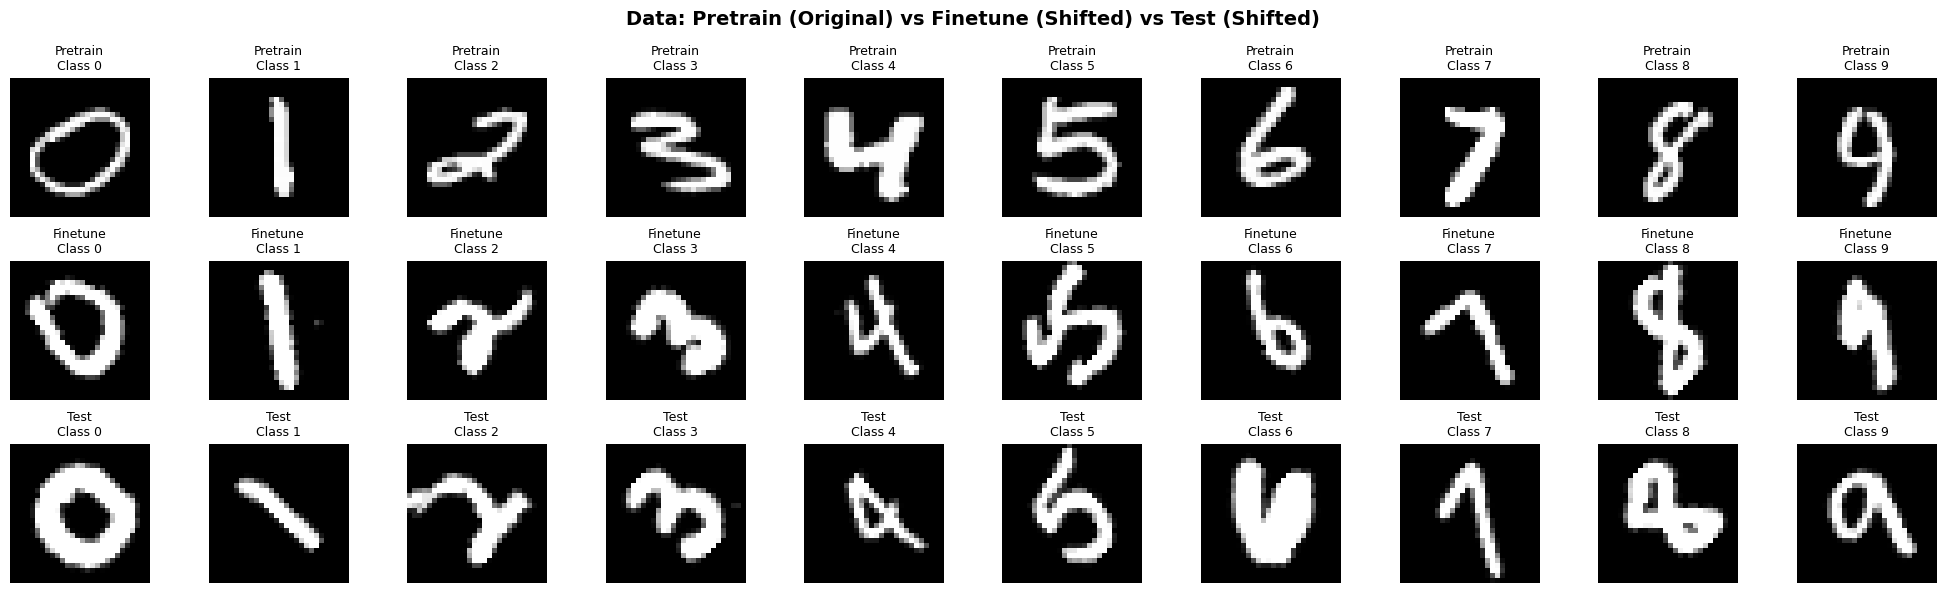


Data visualization saved!


In [2]:

# CONFIGURATION AND DEVICE SETUP

@dataclass
class Config:
    # Data - PRETRAIN
    pretrain_samples: int = 10000
    pretrain_batch_size: int = 128
    
    # Data - FINETUNE (Online Learning)
    finetune_samples: int = 400  # 40 per class
    batch_size: int = 10  # set separetely for every model
    finetune_test_samples: int = 100 # 10 per class
    
    # Full test set size
    n_test_samples: int = 2000

    # Domain Shift
    shift_type: str = 'both'  # 'rotation', 'brightness_contrast', or 'both'
    rotation_angle: float = 45.0
    contrast: float = 1.8
    brightness: float = 0.4

    # Model
    cnn_channels: List[int] = field(default_factory=lambda: [32, 64]) 
    hidden_sizes: List[int] = field(default_factory=lambda: [128])
    num_classes: int = 10
    dropout_rate: float = 0.1

    # Training - PRETRAIN
    pretrain_epochs: int = 10
    pretrain_lr: float = 1e-4

    # Fine Tuning
    adam_epochs: int = 100
    ekf_epochs: int = 1
    dekf_epochs: int = 1
    lora_epochs: int = 30
    lora_ekf_epochs: int = 1
    lora_dekf_epochs: int = 1

    # Learning rates
    finetune_lr: float = 1e-3        # For Adam
    lora_finetune_lr: float = 5e-3   # For LoRA

    # EKF
    prior_variance: float = 0.1
    dynamics_sigma: float = 1e-6
    observation_noise: float = 1e-3

    # LoRA
    lora_rank: int = 7
    lora_alpha: float = 14.0

    # Logging and Checkpointing
    print_batch_metrics: bool = True
    checkpoint_metric: str = 'test_acc'  # 'test_acc' or 'test_loss'
    checkpoint_dir: str = '/mnt/user-data/outputs/checkpoints'
    verify_covariance: bool = True

    seed: int = 42

config = Config()
os.makedirs(config.checkpoint_dir, exist_ok=True)

# Device Setup
def setup_device():
    devices = jax.devices()
    backend = jax_backend.get_backend().platform
    print(f"Backend: {backend.upper()}")
    print(f"Devices: {len(devices)}")
    for i, device in enumerate(devices):
        print(f"  [{i}] {device.device_kind}: {device}")
    if backend == 'gpu':
        print(f"\n GPU acceleration enabled")
    elif backend == 'tpu':
        print(f"\n TPU acceleration enabled")
    else:
        print(f"\n CPU only")
    print("="*80)
    return devices[0], backend

device, backend = setup_device()

# DATA LOADING AND DOMAIN SHIFT

def load_mnist(normalize=True, n_train_samples=None, n_test_samples=None):
    n_train_samples = n_train_samples or config.pretrain_samples
    n_test_samples = n_test_samples or config.n_test_samples

    (X_train, y_train), (X_test, y_test) = tf_mnist.load_data()

    if normalize:
        X_train = X_train.astype(np.float32) / 255.0
        X_test = X_test.astype(np.float32) / 255.0

    X_train = X_train.reshape(-1, 28*28)
    X_test = X_test.reshape(-1, 28*28)

    # Subsample
    rng = np.random.RandomState(config.seed)
    train_idx = rng.choice(len(X_train), n_train_samples, replace=False)
    test_idx = rng.choice(len(X_test), n_test_samples, replace=False)

    X_train = X_train[train_idx]
    y_train = y_train[train_idx]
    X_test = X_test[test_idx]
    y_test = y_test[test_idx]

    X_train = jnp.array(X_train, dtype=jnp.float32)
    X_test = jnp.array(X_test, dtype=jnp.float32)
    y_train = jnp.array(y_train, dtype=jnp.int32)
    y_test = jnp.array(y_test, dtype=jnp.int32)

    print(f"Data loaded:")
    print(f"  Train: {X_train.shape}, dtype={X_train.dtype}")
    print(f"  Test: {X_test.shape}, dtype={X_test.dtype}")

    return X_train, y_train, X_test, y_test

def apply_domain_shift(X, shift_type='brightness_contrast', contrast=1.8, brightness=0.4, rotation_angle=45):
    X_reshaped = X.reshape(-1, 28, 28)

    if shift_type == 'brightness_contrast':
        X_shifted = np.clip(((X_reshaped - 0.5) * contrast + 0.5) + brightness, 0, 1)
    elif shift_type == 'rotation':
        from scipy.ndimage import rotate
        X_shifted = np.array([rotate(img, rotation_angle, reshape=False, order=1, mode='constant', cval=0.0)
                             for img in X_reshaped])
    elif shift_type == 'both':
        from scipy.ndimage import rotate
        X_rotated = np.array([rotate(img, rotation_angle, reshape=False, order=1, mode='constant', cval=0.0)
                             for img in X_reshaped])
        X_shifted = np.clip(((X_rotated - 0.5) * contrast + 0.5) + brightness, 0, 1)
    else:
        X_shifted = X_reshaped

    X_shifted = X_shifted.reshape(-1, 28*28)
    return jnp.array(X_shifted, dtype=jnp.float32)

def stratified_sample(X, y, n_samples, n_classes=10, seed=42):
    n_per_class = n_samples // n_classes
    rng = np.random.RandomState(seed)
    
    # Convert JAX arrays to numpy for easier manipulation
    X_np = np.array(X)
    y_np = np.array(y)
    
    X_sampled = []
    y_sampled = []
    
    for class_label in range(n_classes):
        class_indices = np.where(y_np == class_label)[0]
        
        if len(class_indices) < n_per_class:
            print(f"Warning: Class {class_label} has only {len(class_indices)} samples, requested {n_per_class}")
            selected_indices = class_indices
        else:
            selected_indices = rng.choice(class_indices, n_per_class, replace=False)
        
        X_sampled.append(X_np[selected_indices])
        y_sampled.append(y_np[selected_indices])
    
    X_sampled = np.concatenate(X_sampled, axis=0)
    y_sampled = np.concatenate(y_sampled, axis=0)
    
    # Shuffle
    shuffle_idx = rng.permutation(len(X_sampled))
    X_sampled = X_sampled[shuffle_idx]
    y_sampled = y_sampled[shuffle_idx]
    
    return jnp.array(X_sampled, dtype=jnp.float32), jnp.array(y_sampled, dtype=jnp.int32)

# Load full dataset ONCE using existing function
X_train_full, y_train_full, X_test_full, y_test_full = load_mnist(
    normalize=True, 
    n_train_samples=60000,
    n_test_samples=10000
)

print("="*80)
print("DATA PREPARATION")
print("="*80)


# PRETRAIN DATA
X_train_pretrain, y_train_pretrain = stratified_sample(
    X_train_full, y_train_full, 
    config.pretrain_samples, 
    seed=config.seed
)
X_test_pretrain, y_test_pretrain = stratified_sample(
    X_test_full, y_test_full,
    config.n_test_samples,
    seed=config.seed + 1
)

print(f"\nPRETRAIN DATA (Original MNIST):")
print(f"  Train: {X_train_pretrain.shape[0]} samples ({config.pretrain_samples // 10} per class)")
print(f"  Test:  {X_test_pretrain.shape[0]} samples")
print(f"  Batch size: {config.pretrain_batch_size}")

y_train_full_np = np.array(y_train_full)

used_indices = set()
for class_label in range(10):
    class_indices = np.where(y_train_full_np == class_label)[0]
    used_indices.update(class_indices[:config.pretrain_samples // 10])

# Get unused indices as numpy array for JAX-compatible indexing
unused_indices = np.array(list(set(range(len(X_train_full))) - used_indices))

# Index using numpy array (JAX-compatible)
X_train_unused = X_train_full[unused_indices]
y_train_unused = y_train_full[unused_indices]

X_train_finetune, y_train_finetune = stratified_sample(
    X_train_unused, y_train_unused,
    config.finetune_samples,
    seed=config.seed + 2
)

# Apply domain shift to finetune data
X_train_finetune_shifted = apply_domain_shift(
    X_train_finetune, 
    shift_type=config.shift_type,
    rotation_angle=config.rotation_angle,
    contrast=config.contrast,
    brightness=config.brightness
)

# Small test set (stratified)
X_test_finetune, y_test_finetune = stratified_sample(
    X_test_full, y_test_full,
    config.finetune_test_samples,
    seed=config.seed + 3
)

X_test_finetune_shifted = apply_domain_shift(
    X_test_finetune,
    shift_type=config.shift_type,
    rotation_angle=config.rotation_angle,
    contrast=config.contrast,
    brightness=config.brightness
)

print(f"\nFINETUNE DATA (Shifted, Online Learning):")
print(f"  Train: {X_train_finetune_shifted.shape[0]} samples ({config.finetune_samples // 10} per class)")
print(f"  Test:  {X_test_finetune_shifted.shape[0]} samples ({config.finetune_test_samples // 10} per class)")
print(f"  Batch size: {config.batch_size} (TRUE ONLINE)")
print(f"  Domain shift: {config.shift_type} (angle={config.rotation_angle}°)")

# Verify class distribution
print(f"\nClass distribution (finetune train):")
y_train_finetune_np = np.array(y_train_finetune)
for i in range(10):
    count = int(np.sum(y_train_finetune_np == i))
    print(f"  Class {i}: {count} samples")

print(f"\nClass distribution (finetune test):")
y_test_finetune_np = np.array(y_test_finetune)
for i in range(10):
    count = int(np.sum(y_test_finetune_np == i))
    print(f"  Class {i}: {count} samples")

# VISUALIZATION
fig, axes = plt.subplots(3, 10, figsize=(20, 6))

# Convert to numpy for visualization
X_train_pretrain_np = np.array(X_train_pretrain)
y_train_pretrain_np = np.array(y_train_pretrain)
X_train_finetune_shifted_np = np.array(X_train_finetune_shifted)
X_test_finetune_shifted_np = np.array(X_test_finetune_shifted)

for i in range(10):
    # Row 1: Original pretrain
    idx = int(np.where(y_train_pretrain_np == i)[0][0])
    axes[0, i].imshow(X_train_pretrain_np[idx].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title(f'Pretrain\nClass {i}', fontsize=9)
    
    # Row 2: Shifted finetune
    idx = int(np.where(y_train_finetune_np == i)[0][0])
    axes[1, i].imshow(X_train_finetune_shifted_np[idx].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title(f'Finetune\nClass {i}', fontsize=9)
    
    # Row 3: Shifted test
    idx = int(np.where(y_test_finetune_np == i)[0][0])
    axes[2, i].imshow(X_test_finetune_shifted_np[idx].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')
    axes[2, i].set_title(f'Test\nClass {i}', fontsize=9)

plt.suptitle('Data: Pretrain (Original) vs Finetune (Shifted) vs Test (Shifted)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/data_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nData visualization saved!")

In [3]:

X_train = X_train_pretrain
y_train = y_train_pretrain
X_test = X_test_pretrain
y_test = y_test_pretrain

print(f"Pretrain mapping:")
print(f"  X_train → X_train_pretrain: {X_train.shape}")
print(f"  y_train → y_train_pretrain: {y_train.shape}")
print(f"  X_test  → X_test_pretrain:  {X_test.shape}")
print(f"  y_test  → y_test_pretrain:  {y_test.shape}")

X_train_shifted = X_train_finetune_shifted
y_train_shifted = y_train_finetune  
X_test_shifted = X_test_finetune_shifted
y_test_shifted = y_test_finetune

print(f"\nFinetune mapping:")
print(f"  X_train_shifted → X_train_finetune_shifted: {X_train_shifted.shape}")
print(f"  y_train_shifted → y_train_finetune:         {y_train_shifted.shape}")
print(f"  X_test_shifted  → X_test_finetune_shifted:  {X_test_shifted.shape}")
print(f"  y_test_shifted  → y_test_finetune:          {y_test_shifted.shape}")

print(f"  Pretrain: {X_train.shape[0]} train samples, {X_test.shape[0]} test samples")
print(f"  Finetune: {X_train_shifted.shape[0]} train samples, {X_test_shifted.shape[0]} test samples (ONLINE)")
print(f"  Batch sizes: Pretrain={config.pretrain_batch_size}, Finetune={config.batch_size}")

Pretrain mapping:
  X_train → X_train_pretrain: (10000, 784)
  y_train → y_train_pretrain: (10000,)
  X_test  → X_test_pretrain:  (2000, 784)
  y_test  → y_test_pretrain:  (2000,)

Finetune mapping:
  X_train_shifted → X_train_finetune_shifted: (400, 784)
  y_train_shifted → y_train_finetune:         (400,)
  X_test_shifted  → X_test_finetune_shifted:  (100, 784)
  y_test_shifted  → y_test_finetune:          (100,)
  Pretrain: 10000 train samples, 2000 test samples
  Finetune: 400 train samples, 100 test samples (ONLINE)
  Batch sizes: Pretrain=128, Finetune=10


In [4]:
# MODEL DEFINITION AND UTILITIES

class CNN_MLP(nnx.Module):
    def __init__(self, 
                 cnn_channels: List[int],
                 mlp_hidden_sizes: List[int],
                 num_classes: int, 
                 rngs: nnx.Rngs,
                 dropout_rate: float = 0.1):
        
        self.cnn_channels = cnn_channels
        self.mlp_hidden_sizes = mlp_hidden_sizes
        self.num_classes = num_classes
        self.dropout_rate = dropout_rate
        
        self.conv1 = nnx.Conv(
            in_features=1,
            out_features=cnn_channels[0],
            kernel_size=(3, 3),
            strides=(1, 1),
            padding='SAME',
            rngs=rngs
        )
        
        self.conv2 = nnx.Conv(
            in_features=cnn_channels[0],
            out_features=cnn_channels[1],
            kernel_size=(3, 3),
            strides=(1, 1),
            padding='SAME',
            rngs=rngs
        )
        
        flatten_size = 7 * 7 * cnn_channels[1]
        

        self.mlp_layers = []
        in_features = flatten_size
        
        for hidden_size in mlp_hidden_sizes:
            self.mlp_layers.append(
                nnx.Linear(in_features, hidden_size, rngs=rngs)
            )
            in_features = hidden_size
        
        self.output = nnx.Linear(in_features, num_classes, rngs=rngs)
        
        # Dropout
        self.dropout = nnx.Dropout(rate=dropout_rate, rngs=rngs)
    
    def __call__(self, x, training: bool = False):
        features = self.extract_features(x)
        
        if training:
            features = self.dropout(features)
        
        return self.output(features)
    
    def extract_features(self, x):
        original_shape = x.shape
        is_single_sample = (x.ndim == 1)
        
        if is_single_sample:
            x = jnp.expand_dims(x, axis=0)
        
        batch_size = x.shape[0]
        
        x = x.reshape(batch_size, 28, 28, 1)
        
        x = self.conv1(x)
        x = nnx.relu(x)
        x = nnx.max_pool(x, window_shape=(2, 2), strides=(2, 2))
        
        x = self.conv2(x)
        x = nnx.relu(x)
        x = nnx.max_pool(x, window_shape=(2, 2), strides=(2, 2))
        
        x = x.reshape(batch_size, -1)
        
        for layer in self.mlp_layers:
            x = layer(x)
            x = nnx.relu(x)
        
        if is_single_sample:
            x = jnp.squeeze(x, axis=0)
        
        return x


# Loss and Metrics
@jit
def cross_entropy_loss(logits, labels):
    one_hot = jax.nn.one_hot(labels, config.num_classes)
    return -jnp.mean(jnp.sum(one_hot * jax.nn.log_softmax(logits), axis=-1)) # axis = -1 is the num classes

@jit
def compute_accuracy(logits, labels):
    predictions = jnp.argmax(logits, axis=-1)
    return jnp.mean(predictions == labels)

# Covariance Verification
def verify_covariance_matrix(P, name="P", step=0):
    if not config.verify_covariance:
        return

    is_symmetric = jnp.allclose(P, P.T, atol=1e-6) 

    eigenvalues = jnp.linalg.eigvalsh(P)

    min_eigenvalue = jnp.min(eigenvalues)
    is_psd = min_eigenvalue >= -1e-6
    trace = jnp.trace(P) 
    frobenius_norm = jnp.linalg.norm(P, 'fro')

    if step % 50 == 0:
        print(f"    [{name} @step {step}] Symmetric: {is_symmetric}, PSD: {is_psd}, "
              f"Tr: {trace:.2e}, ||P||_F: {frobenius_norm:.2e}, λ_min: {min_eigenvalue:.2e}")

    if not is_symmetric:
        print(f"    WARNING: {name} is not symmetric at step {step}!")
    if not is_psd:
        print(f"    WARNING: {name} is not PSD at step {step}! Min eigenvalue: {min_eigenvalue:.2e}")

def compare_covariances(P_prev, P_curr, name="P", step=0):
    if not config.verify_covariance or P_prev is None:
        return

    diff_norm = jnp.linalg.norm(P_curr - P_prev, 'fro')
    relative_change = diff_norm / (jnp.linalg.norm(P_prev, 'fro') + 1e-10)

    if step % 50 == 0:
        print(f"    [{name} @step {step}] ||P_curr - P_prev||_F: {diff_norm:.2e}, "
              f"Relative change: {relative_change:.4f}")

print("Model and utilities defined")

Model and utilities defined


In [5]:

class TrainState(train_state.TrainState):
    graphdef: Any = None
    output_graphdef: Any = None
    full_other_states: Any = None
    output_other_states: Any = None

def create_train_state(model, learning_rate):
    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    tx = optax.adam(learning_rate)
    def apply_fn(params, x, training=False):
        model_copy = nnx.merge(graphdef, params, other_states)
        return model_copy(x, training=training)
    return TrainState.create(
        apply_fn=apply_fn,
        params=params,
        tx=tx,
        graphdef=graphdef
    )

def create_output_only_train_state(model, learning_rate):
    output_layer = model.output
    output_graphdef, output_params, output_other_states = nnx.split(output_layer, nnx.Param, ...)

    full_graphdef, full_params, full_other_states = nnx.split(model, nnx.Param, ...)

    #tx = optax.adam(learning_rate)
    tx = optax.adamw(learning_rate=learning_rate, weight_decay=0.01)


    def apply_fn(output_params, x, training=False):
        # Reconstruct frozen base model
        model_copy = nnx.merge(full_graphdef, full_params, full_other_states)
        # Extract features WITHOUT dropout (eval mode for frozen layers)
        features = model_copy.extract_features(x)
        # Apply trainable output layer
        output_layer_updated = nnx.merge(output_graphdef, output_params, output_other_states)
        logits = output_layer_updated(features)
        return logits

    return TrainState.create(
        apply_fn=apply_fn,
        params=output_params,
        tx=tx,
        graphdef=full_graphdef,
        output_graphdef=output_graphdef,
        full_other_states=full_other_states,
        output_other_states=output_other_states
    )

# For PRETRAINING (with dropout)
@jit
def pretrain_step(state, batch):
    x, y = batch
    def loss_fn(params):
        logits = state.apply_fn(params, x, training=True)  # Enable dropout
        return cross_entropy_loss(logits, y)

    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    logits = state.apply_fn(state.params, x, training=False)  # Eval mode for metrics
    acc = compute_accuracy(logits, y)
    return state, loss, acc


@jit
def finetune_step(state, batch):
    x, y = batch
    def loss_fn(params):
        logits = state.apply_fn(params, x, training=False)  # Avoid stale dropout
        return cross_entropy_loss(logits, y)

    loss, grads = jax.value_and_grad(loss_fn)(state.params)
    state = state.apply_gradients(grads=grads)
    logits = state.apply_fn(state.params, x, training=False)
    acc = compute_accuracy(logits, y)
    return state, loss, acc

@jit
def eval_step(state, batch):
    x, y = batch
    logits = state.apply_fn(state.params, x, training=False)
    loss = cross_entropy_loss(logits, y)
    acc = compute_accuracy(logits, y)
    return loss, acc

print("Training utilities defined")

Training utilities defined


In [6]:
# PRETRAINING

writer = SummaryWriter('/mnt/user-data/outputs/runs')

def pretrain_model(X_train, y_train, X_test, y_test, writer=None):
    print("\n" + "="*80)
    print("PRETRAINING")
    print("="*80)

    rng = nnx.Rngs(config.seed)
    #model = MLP(config.hidden_sizes, config.num_classes, rng)
    model = CNN_MLP(
    cnn_channels=config.cnn_channels,
    mlp_hidden_sizes=config.hidden_sizes,
    num_classes=config.num_classes,
    rngs=rng,
    dropout_rate=config.dropout_rate)

    state = create_train_state(model, config.pretrain_lr)

    # OLD: n_batches = len(X_train) // config.batch_size  # Drops last incomplete batch
    # NEW: Include last batch even if incomplete
    n_batches = int(np.ceil(len(X_train) / config.pretrain_batch_size))

    for epoch in range(config.pretrain_epochs):
        key = random.PRNGKey(epoch + config.seed)
        perm = random.permutation(key, len(X_train))
        X_shuffled = X_train[perm]
        y_shuffled = y_train[perm]

        epoch_loss = 0.0
        epoch_acc = 0.0

        for i in range(n_batches):
            start_idx = i * config.pretrain_batch_size
            end_idx = min((i + 1) * config.pretrain_batch_size, len(X_train))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]

            #state, loss, acc = train_step(state, (batch_x, batch_y))
            state, loss, acc = pretrain_step(state, (batch_x, batch_y))
            epoch_loss += loss
            epoch_acc += acc

        epoch_loss /= n_batches
        epoch_acc /= n_batches
        test_loss, test_acc = eval_step(state, (X_test, y_test))

        print(f"Epoch {epoch+1}/{config.pretrain_epochs} | "
              f"Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f} | "
              f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

        if writer:
            writer.add_scalar('pretrain/train_loss', float(epoch_loss), epoch)
            writer.add_scalar('pretrain/train_acc', float(epoch_acc), epoch)
            writer.add_scalar('pretrain/test_loss', float(test_loss), epoch)
            writer.add_scalar('pretrain/test_acc', float(test_acc), epoch)

    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    final_model = nnx.merge(graphdef, state.params, other_states)
    return final_model, float(test_acc), float(test_loss)

# Run pretraining
pretrained_model, pretrain_acc, pretrain_loss = pretrain_model(
    X_train, y_train, X_test, y_test, writer
)

print(f"\nPretrained model: Acc={pretrain_acc:.4f}, Loss={pretrain_loss:.4f}")

# Evaluate on shifted data (baseline)
test_logits = pretrained_model(X_test_shifted, training=False)
baseline_acc = float(compute_accuracy(test_logits, y_test_shifted))
baseline_loss = float(cross_entropy_loss(test_logits, y_test_shifted))
print(f"Baseline on shifted data: Acc={baseline_acc:.4f}, Loss={baseline_loss:.4f}")


PRETRAINING
Epoch 1/10 | Train Loss: 1.3598 | Train Acc: 0.6988 | Test Loss: 0.6180 | Test Acc: 0.8505
Epoch 2/10 | Train Loss: 0.5118 | Train Acc: 0.8765 | Test Loss: 0.3325 | Test Acc: 0.9160
Epoch 3/10 | Train Loss: 0.3481 | Train Acc: 0.9137 | Test Loss: 0.2495 | Test Acc: 0.9325
Epoch 4/10 | Train Loss: 0.2730 | Train Acc: 0.9314 | Test Loss: 0.1933 | Test Acc: 0.9515
Epoch 5/10 | Train Loss: 0.2291 | Train Acc: 0.9444 | Test Loss: 0.1760 | Test Acc: 0.9555
Epoch 6/10 | Train Loss: 0.2005 | Train Acc: 0.9499 | Test Loss: 0.1441 | Test Acc: 0.9640
Epoch 7/10 | Train Loss: 0.1764 | Train Acc: 0.9566 | Test Loss: 0.1325 | Test Acc: 0.9680
Epoch 8/10 | Train Loss: 0.1547 | Train Acc: 0.9633 | Test Loss: 0.1188 | Test Acc: 0.9670
Epoch 9/10 | Train Loss: 0.1361 | Train Acc: 0.9668 | Test Loss: 0.1106 | Test Acc: 0.9675
Epoch 10/10 | Train Loss: 0.1265 | Train Acc: 0.9697 | Test Loss: 0.1035 | Test Acc: 0.9715

Pretrained model: Acc=0.9715, Loss=0.1035
Baseline on shifted data: Acc=0.3

In [7]:
# CHECKPOINT UTILITIES

def save_checkpoint(method, model, metrics, covariances=None, epoch=0):
    checkpoint_path = os.path.join(config.checkpoint_dir, f"{method}_best.npz")

    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    flat_params, _ = ravel_pytree(params)

    if covariances is not None:
        if isinstance(covariances, dict):
            covariances_np = {k: np.array(v) for k, v in covariances.items()}
        else:
            covariances_np = np.array(covariances)
    else:
        covariances_np = None

    save_dict = {
        'params': np.array(flat_params),
        'metrics_acc': metrics['test_acc'],
        'metrics_loss': metrics['test_loss'],
        'epoch': epoch,
        'method': method
    }

    if covariances_np is not None:
        if isinstance(covariances_np, dict):
            for k, v in covariances_np.items():
                save_dict[f'cov_{k}'] = v
        else:
            save_dict['cov'] = covariances_np

    np.savez(checkpoint_path, **save_dict)

    graphdef_path = os.path.join(config.checkpoint_dir, f"{method}_graphdef.pkl")
    if not os.path.exists(graphdef_path):
        try:
            with open(graphdef_path, 'wb') as f:
                pickle.dump({'graphdef': graphdef, 'other_states': other_states}, f)
        except Exception as e:
            print(f"    Warning: Could not pickle graphdef: {e}")
            with open(graphdef_path, 'wb') as f:
                pickle.dump({'method': method}, f)

    print(f"Checkpoint saved: {checkpoint_path} (epoch {epoch}, {config.checkpoint_metric}={metrics[config.checkpoint_metric]:.4f})")

def load_checkpoint(method, model_template):
    checkpoint_path = os.path.join(config.checkpoint_dir, f"{method}_best.npz")

    if not os.path.exists(checkpoint_path):
        print(f"No checkpoint found: {checkpoint_path}")
        return None, None

    checkpoint = np.load(checkpoint_path)
    flat_params_np = checkpoint['params']
    flat_params = jnp.array(flat_params_np)

    graphdef, current_params, other_states = nnx.split(model_template, nnx.Param, ...)
    _, unflatten_fn = ravel_pytree(current_params)
    restored_params = unflatten_fn(flat_params)
    model = nnx.merge(graphdef, restored_params, other_states)

    covariances = None
    if 'cov' in checkpoint.files:
        covariances = jnp.array(checkpoint['cov'])
    elif any(f.startswith('cov_') for f in checkpoint.files):
        covariances = {}
        for f in checkpoint.files:
            if f.startswith('cov_'):
                key = f[4:]
                covariances[key] = jnp.array(checkpoint[f])

    epoch = int(checkpoint['epoch'])
    print(f"Checkpoint loaded: {checkpoint_path} (epoch {epoch})")

    return model, covariances

print("Checkpoint utilities defined")

Checkpoint utilities defined


In [8]:
# ADAM FINE-TUNING

print("\n" + "="*80)
print("ADAM FINE-TUNING")
print("="*80)

config.print_batch_metrics = False
config.finetune_lr = 2e-4 #5e-4/10 , 2e-4/1
config.batch_size = 1
config.adam_epochs = 100
adam_model = nnx.clone(pretrained_model)
adam_state = create_output_only_train_state(adam_model, config.finetune_lr)
adam_losses, adam_accs = [], []
adam_test_accs_per_epoch = []
adam_test_losses_per_epoch = []
start_time = time.time()
total_steps = 0
best_metric = -float('inf') if config.checkpoint_metric == 'test_acc' else float('inf')

# OLD: n_batches_per_epoch = len(X_train_shifted) // config.batch_size
# NEW: Include last incomplete batch
n_batches_per_epoch = int(np.ceil(len(X_train_shifted) / config.batch_size))

#for epoch in range(config.finetune_epochs):
for epoch in range(config.adam_epochs):
    key = random.PRNGKey(epoch + config.seed + 1000)
    perm = random.permutation(key, len(X_train_shifted))
    X_shuffled = X_train_shifted[perm]
    y_shuffled = y_train_shifted[perm]

    epoch_loss = 0.0
    epoch_acc = 0.0

    for batch_idx in range(n_batches_per_epoch):
        start_idx = batch_idx * config.batch_size
        end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted))
        batch_x = X_shuffled[start_idx:end_idx]
        batch_y = y_shuffled[start_idx:end_idx]

        #adam_state, loss, acc = train_step(adam_state, (batch_x, batch_y))
        adam_state, loss, acc = finetune_step(adam_state, (batch_x, batch_y))
        adam_losses.append(float(loss))
        adam_accs.append(float(acc))

        epoch_loss += loss
        epoch_acc += acc

        if config.print_batch_metrics:
            print(f"  Epoch {epoch+1}/{config.adam_epochs} | Batch {batch_idx+1}/{n_batches_per_epoch} | "
                  f"Loss: {float(loss):.4f} | Acc: {float(acc):.4f}")

        if writer:
            writer.add_scalar('adam/loss', float(loss), total_steps)
            writer.add_scalar('adam/acc', float(acc), total_steps)

        total_steps += 1

    epoch_loss /= n_batches_per_epoch
    epoch_acc /= n_batches_per_epoch

    # Evaluate
    test_logits = adam_state.apply_fn(adam_state.params, X_test_shifted, training=False)
    test_acc = float(compute_accuracy(test_logits, y_test_shifted))
    test_loss = float(cross_entropy_loss(test_logits, y_test_shifted))

    adam_test_accs_per_epoch.append(test_acc)
    adam_test_losses_per_epoch.append(test_loss)

    print(f"  Epoch {epoch+1}/{config.adam_epochs} | Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    # Checkpointing
    current_metric = test_acc if config.checkpoint_metric == 'test_acc' else test_loss
    if (config.checkpoint_metric == 'test_acc' and current_metric > best_metric) or \
       (config.checkpoint_metric == 'test_loss' and current_metric < best_metric):
        best_metric = current_metric
        # Reconstruct full model for checkpointing
        output_layer_updated = nnx.merge(adam_state.output_graphdef, adam_state.params, adam_state.output_other_states)
        temp_model = nnx.clone(adam_model)
        temp_model.output = output_layer_updated
        save_checkpoint('adam', temp_model, {'test_acc': test_acc, 'test_loss': test_loss},
                      covariances=None, epoch=epoch)

adam_time = time.time() - start_time

# Load best checkpoint
best_adam_model, _ = load_checkpoint('adam', adam_model)
if best_adam_model is not None:
    adam_model = best_adam_model

# Final evaluation
test_logits = adam_model(X_test_shifted, training=False)
adam_test_acc = float(compute_accuracy(test_logits, y_test_shifted))
adam_test_loss = float(cross_entropy_loss(test_logits, y_test_shifted))

adam_results = {
    'losses': adam_losses,
    'accs': adam_accs,
    'test_acc': adam_test_acc,
    'test_loss': adam_test_loss,
    'time': adam_time,
    'model': adam_model,
    'test_accs_per_epoch': adam_test_accs_per_epoch,
    'test_losses_per_epoch': adam_test_losses_per_epoch
}

print(f"\nADAM Final: Acc={adam_test_acc:.4f}, Loss={adam_test_loss:.4f}, Time={adam_time:.2f}s")


ADAM FINE-TUNING
  Epoch 1/100 | Train Loss: 1.9970 | Train Acc: 0.4175 | Test Loss: 2.1486 | Test Acc: 0.3900
Checkpoint saved: /mnt/user-data/outputs/checkpoints/adam_best.npz (epoch 0, test_acc=0.3900)
  Epoch 2/100 | Train Loss: 1.6527 | Train Acc: 0.4925 | Test Loss: 1.8624 | Test Acc: 0.4500
Checkpoint saved: /mnt/user-data/outputs/checkpoints/adam_best.npz (epoch 1, test_acc=0.4500)
  Epoch 3/100 | Train Loss: 1.4416 | Train Acc: 0.5400 | Test Loss: 1.6271 | Test Acc: 0.5200
Checkpoint saved: /mnt/user-data/outputs/checkpoints/adam_best.npz (epoch 2, test_acc=0.5200)
  Epoch 4/100 | Train Loss: 1.2810 | Train Acc: 0.5825 | Test Loss: 1.4566 | Test Acc: 0.5400
Checkpoint saved: /mnt/user-data/outputs/checkpoints/adam_best.npz (epoch 3, test_acc=0.5400)
  Epoch 5/100 | Train Loss: 1.1571 | Train Acc: 0.6225 | Test Loss: 1.3072 | Test Acc: 0.5500
Checkpoint saved: /mnt/user-data/outputs/checkpoints/adam_best.npz (epoch 4, test_acc=0.5500)
  Epoch 6/100 | Train Loss: 1.0480 | Train

In [9]:
baseline_check = float(compute_accuracy(pretrained_model(X_test_shifted, training=False), y_test_shifted))
print(f"Baseline check: {baseline_check:.4f}")

Baseline check: 0.3700


In [10]:
# EKF SETUP AND UPDATE FUNCTIONS

class ParameterGroup:
    def __init__(self, name, flat_params, unflatten_fn, prior_var, dynamic_sigma):
        self.name = name
        self.flat_params = flat_params
        self.unflatten_fn = unflatten_fn
        self.state_dim = flat_params.size
        self.initial_mean = flat_params
        self.initial_covariance = jnp.eye(self.state_dim) * prior_var
        self.dynamics_function = lambda w, x: w
        self.dynamics_covariance = jnp.eye(self.state_dim) * dynamic_sigma

def ekf_update(model, X_batch, y_batch, P_previous=None, use_full_cov=True, step=0):

    output_layer = model.output
    output_state = nnx.state(output_layer, nnx.Param)

    flat_params, unflatten_fn = ravel_pytree(output_state)
    state_dim = flat_params.size

    def forward_fn(params_flat, x):
        params_unflat = unflatten_fn(params_flat)
        output_graphdef, _, other_states = nnx.split(output_layer, nnx.Param, ...)
        output_layer_temp = nnx.merge(output_graphdef, params_unflat, other_states)
        features = model.extract_features(x)
        logits = output_layer_temp(features)
        return jax.nn.softmax(logits)

    initial_mean = flat_params

    if P_previous is None:
        initial_covariance = jnp.eye(state_dim) * config.prior_variance
        print(f"  [EKF] Initializing covariance: P0 = {config.prior_variance} × I ({state_dim}×{state_dim})")
    else:
        initial_covariance = P_previous
        verify_covariance_matrix(P_previous, "P_prev", step)

    dynamics_function = lambda w, x: w # no params drift
    dynamics_covariance = jnp.eye(state_dim) * config.dynamics_sigma

    def emission_mean_function(w, x):
        return forward_fn(w, x)

    # def emission_cov_function(w, x):
    #     probs = emission_mean_function(w, x)
    #     return jnp.diag(probs * (1 - probs)) + config.observation_noise * jnp.eye(config.num_classes)

    def emission_cov_function(w, x):
        probs = emission_mean_function(w, x)
        
        # Calculate entropy (uncertainty measure)
        entropy = -jnp.sum(probs * jnp.log(probs + 1e-10))
        max_entropy = jnp.log(float(config.num_classes))
        
        # Adaptive noise: higher when uncertain (1.3 best)
        adaptive_noise = config.observation_noise * (1.0 + 0.3 * entropy / max_entropy)
        
        return jnp.diag(probs * (1 - probs)) + adaptive_noise * jnp.eye(config.num_classes)

    params = ParamsGGSSM(
        initial_mean=initial_mean,
        initial_covariance=initial_covariance,
        dynamics_function=dynamics_function,
        dynamics_covariance=dynamics_covariance,
        emission_mean_function=emission_mean_function,
        emission_cov_function=emission_cov_function
    )
    # conditional_moments_gaussian_filter uses:
    #   num_timesteps = len(emissions)  --> here len(emissions) == B
    #   lax.scan over jnp.arange(num_timesteps)
    #   inside scan: y = emissions[t]  (shape (D_y,)), u = inputs[t]  (shape (D_x,))
    #
    # Effect: The mini-batch of size B is processed sequentially as T = B time-steps.

    emissions = jax.nn.one_hot(y_batch, config.num_classes)
    inputs = X_batch

    ekf_post = conditional_moments_gaussian_filter(
        params,
        EKFIntegrals(),
        emissions,
        inputs
    )

    updated_params_flat = ekf_post.filtered_means[-1]
    updated_covariance = ekf_post.filtered_covariances[-1]

    verify_covariance_matrix(updated_covariance, "P_updated", step)
    compare_covariances(P_previous, updated_covariance, "P_EKF", step)

    updated_params = unflatten_fn(updated_params_flat)
    nnx.update(output_layer, updated_params)

    return model, updated_covariance

print("EKF update function defined")

EKF update function defined


In [11]:
# EKF FINE-TUNING

print("\n" + "="*80)
print("EKF FINE-TUNING (LAST LAYER ONLY)")
print("="*80)

config.prior_variance = 1.0
config.dynamics_sigma = 5e-4 # 5e-4
config.observation_noise = 7e-2#7e-2 , 3e-2
config.ekf_epochs = 3 # 3,4
config.print_batch_metrics = False
config.batch_size = 400
ekf_model = nnx.clone(pretrained_model)
ekf_losses, ekf_accs = [], []
ekf_test_accs_per_epoch = []
ekf_test_losses_per_epoch = []
ekf_traces_per_epoch = []
start_time = time.time()
total_steps = 0
best_metric = -float('inf') if config.checkpoint_metric == 'test_acc' else float('inf')
P_ekf = None
best_P_ekf = None

n_batches_per_epoch = int(np.ceil(len(X_train_shifted) / config.batch_size))

#for epoch in range(config.finetune_epochs):
for epoch in range(config.ekf_epochs):
    key = random.PRNGKey(epoch + config.seed + 2000)
    perm = random.permutation(key, len(X_train_shifted))
    X_shuffled = X_train_shifted[perm]
    y_shuffled = y_train_shifted[perm]

    epoch_loss = 0.0
    epoch_acc = 0.0

    for batch_idx in range(n_batches_per_epoch):
        start_idx = batch_idx * config.batch_size
        end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted))
        batch_x = X_shuffled[start_idx:end_idx]
        batch_y = y_shuffled[start_idx:end_idx]

        P_ekf_prev = P_ekf
        ekf_model, P_ekf = ekf_update(ekf_model, batch_x, batch_y, P_ekf, use_full_cov=True, step=total_steps)

        logits = ekf_model(batch_x, training=False)
        loss = float(cross_entropy_loss(logits, batch_y))
        acc = float(compute_accuracy(logits, batch_y))
        ekf_losses.append(loss)
        ekf_accs.append(acc)

        epoch_loss += loss
        epoch_acc += acc

        if config.print_batch_metrics:
            trace_P = float(jnp.trace(P_ekf))
            print(f"  Epoch {epoch+1}/{config.ekf_epochs} | Batch {batch_idx+1}/{n_batches_per_epoch} | "
                  f"Loss: {loss:.4f} | Acc: {acc:.4f} | Tr(P): {trace_P:.2e}")

        if writer:
            writer.add_scalar('ekf/loss', loss, total_steps)
            writer.add_scalar('ekf/acc', acc, total_steps)
            writer.add_scalar('ekf/trace_P', float(jnp.trace(P_ekf)), total_steps)

        total_steps += 1

    epoch_loss /= n_batches_per_epoch
    epoch_acc /= n_batches_per_epoch

    # Evaluate
    test_logits = ekf_model(X_test_shifted, training=False)
    test_acc = float(compute_accuracy(test_logits, y_test_shifted))
    test_loss = float(cross_entropy_loss(test_logits, y_test_shifted))

    ekf_test_accs_per_epoch.append(test_acc)
    ekf_test_losses_per_epoch.append(test_loss)
    trace_P = float(jnp.trace(P_ekf))
    ekf_traces_per_epoch.append(trace_P)

    print(f"  Epoch {epoch+1}/{config.ekf_epochs} | Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | Tr(P): {trace_P:.2e}")

    # Checkpointing
    current_metric = test_acc if config.checkpoint_metric == 'test_acc' else test_loss
    if (config.checkpoint_metric == 'test_acc' and current_metric > best_metric) or \
       (config.checkpoint_metric == 'test_loss' and current_metric < best_metric):
        best_metric = current_metric
        best_P_ekf = P_ekf
        save_checkpoint('ekf', ekf_model, {'test_acc': test_acc, 'test_loss': test_loss},
                      covariances={'P': P_ekf}, epoch=epoch)

ekf_time = time.time() - start_time

# Load best checkpoint
best_ekf_model, covariances = load_checkpoint('ekf', ekf_model)
if best_ekf_model is not None:
    ekf_model = best_ekf_model
    P_ekf = covariances['P'] if covariances else P_ekf

# Final evaluation
test_logits = ekf_model(X_test_shifted, training=False)
ekf_test_acc = float(compute_accuracy(test_logits, y_test_shifted))
ekf_test_loss = float(cross_entropy_loss(test_logits, y_test_shifted))

ekf_results = {
    'losses': ekf_losses,
    'accs': ekf_accs,
    'test_acc': ekf_test_acc,
    'test_loss': ekf_test_loss,
    'time': ekf_time,
    'model': ekf_model,
    'covariance': P_ekf,
    'test_accs_per_epoch': ekf_test_accs_per_epoch,
    'test_losses_per_epoch': ekf_test_losses_per_epoch,
    'traces_per_epoch': ekf_traces_per_epoch
}

print(f"\nEKF Final: Acc={ekf_test_acc:.4f}, Loss={ekf_test_loss:.4f}, Time={ekf_time:.2f}s")


EKF FINE-TUNING (LAST LAYER ONLY)
  [EKF] Initializing covariance: P0 = 1.0 × I (1290×1290)
    [P_updated @step 0] Symmetric: True, PSD: True, Tr: 1.32e+03, ||P||_F: 3.85e+01, λ_min: 5.77e-03
  Epoch 1/3 | Train Loss: 0.5533 | Train Acc: 0.9075 | Test Loss: 0.5622 | Test Acc: 0.7900 | Tr(P): 1.32e+03
Checkpoint saved: /mnt/user-data/outputs/checkpoints/ekf_best.npz (epoch 0, test_acc=0.7900)
  Epoch 2/3 | Train Loss: 0.2587 | Train Acc: 0.9725 | Test Loss: 0.4367 | Test Acc: 0.8700 | Tr(P): 1.48e+03
Checkpoint saved: /mnt/user-data/outputs/checkpoints/ekf_best.npz (epoch 1, test_acc=0.8700)
  Epoch 3/3 | Train Loss: 0.2403 | Train Acc: 0.9575 | Test Loss: 0.5909 | Test Acc: 0.8200 | Tr(P): 1.68e+03
Checkpoint loaded: /mnt/user-data/outputs/checkpoints/ekf_best.npz (epoch 1)

EKF Final: Acc=0.8700, Loss=0.4367, Time=10.50s


In [12]:
baseline_check = float(compute_accuracy(pretrained_model(X_test_shifted, training=False), y_test_shifted))
print(f"Baseline check: {baseline_check:.4f}")

Baseline check: 0.3700


In [13]:

def create_lora_model(base_model, rank, alpha):
    rng = nnx.Rngs(config.seed + 1)

    lora_model = nnx.clone(base_model)

    in_features = base_model.output.in_features
    out_features = base_model.output.out_features

    original_kernel = base_model.output.kernel.value
    original_bias = base_model.output.bias.value

    lora_layer = nnx.LoRALinear(
        in_features=in_features,
        out_features=out_features,
        lora_rank=rank,
        rngs=rng
    )

    # Copy pretrained weights
    lora_layer.kernel.value = original_kernel
    lora_layer.bias.value = original_bias

    # Apply alpha scaling
    lora_layer.lora_scale = alpha / rank

    lora_model.output = lora_layer

    print(f"  LoRA layer initialized with pretrained weights")
    print(f"  LoRA scaling factor: {alpha}/{rank} = {alpha/rank:.4f}")

    return lora_model


# LORA FINE-TUNING

print("\n" + "="*80)
print("LORA FINE-TUNING (LAST LAYER ONLY, NATIVE NNX)")
print("="*80)

config.print_batch_metrics = False
config.lora_finetune_lr = 2e-4 #5e-4/10 , 2e-4/1
config.batch_size = 1
config.lora_epochs = 150
config.lora_rank = 7
config.lora_alpha = 7
lora_model = create_lora_model(pretrained_model, config.lora_rank, config.lora_alpha)

print(f"  LoRA configuration: rank={config.lora_rank}, alpha={config.lora_alpha}")

# Get all LoRA-specific trainable parameters
def is_lora_trainable(path, value):
    path_str = '/'.join(str(p) for p in path)
    # Include LoRA-specific parameters
    if 'lora' in path_str.lower():
        return True
    # Include output layer bias
    if 'output' in path_str and 'bias' in path_str:
        return True
    return False

# Split to get trainable params
graphdef, trainable_params, frozen_params = nnx.split(lora_model, is_lora_trainable, ...)

# Count parameters
def count_params(pytree):
    return sum(v.value.size if hasattr(v, 'value') else v.size
               for v in jax.tree.leaves(pytree))

all_state = nnx.state(lora_model, nnx.Param)
lora_count = count_params(trainable_params)
all_count = sum(v.size for v in jax.tree.leaves(all_state))

print(f"  LoRA trainable params: {lora_count:,}")
print(f"  Total params: {all_count:,}")
print(f"  LoRA efficiency: {100 * lora_count / all_count:.2f}%")

lora_losses, lora_accs = [], []
lora_test_accs_per_epoch = []
lora_test_losses_per_epoch = []
start_time = time.time()
total_steps = 0
best_metric = -float('inf') if config.checkpoint_metric == 'test_acc' else float('inf')

n_batches_per_epoch = int(np.ceil(len(X_train_shifted) / config.batch_size))

# Create optimizer
tx = optax.adam(config.lora_finetune_lr)
opt_state = tx.init(trainable_params)

# JIT-compiled training step
@jit
def lora_train_step_jitted(graphdef, trainable_params, frozen_params, opt_state, batch):
    x, y = batch

    def loss_fn(current_trainable_params):
        model_temp = nnx.merge(graphdef, current_trainable_params, frozen_params)
        logits = model_temp(x, training=False)
        return cross_entropy_loss(logits, y)

    # Compute loss and gradients
    loss, grads = jax.value_and_grad(loss_fn)(trainable_params)

    # Update trainable params
    updates, new_opt_state = tx.update(grads, opt_state, trainable_params)
    new_trainable_params = optax.apply_updates(trainable_params, updates)

    # Compute accuracy
    model_acc = nnx.merge(graphdef, new_trainable_params, frozen_params)
    logits_acc = model_acc(x, training=False)
    acc = compute_accuracy(logits_acc, y)

    return new_trainable_params, new_opt_state, loss, acc

print("  JIT-compiled LoRA training step defined")

#for epoch in range(config.finetune_epochs):
for epoch in range(config.lora_epochs):
    key = random.PRNGKey(epoch + config.seed + 4000)
    perm = random.permutation(key, len(X_train_shifted))
    X_shuffled = X_train_shifted[perm]
    y_shuffled = y_train_shifted[perm]

    epoch_loss = 0.0
    epoch_acc = 0.0

    for batch_idx in range(n_batches_per_epoch):
        start_idx = batch_idx * config.batch_size
        end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted))
        batch_x = X_shuffled[start_idx:end_idx]
        batch_y = y_shuffled[start_idx:end_idx]

        trainable_params, opt_state, loss, acc = lora_train_step_jitted(
            graphdef, trainable_params, frozen_params, opt_state, (batch_x, batch_y)
        )

        lora_losses.append(float(loss))
        lora_accs.append(float(acc))

        epoch_loss += loss
        epoch_acc += acc

        if config.print_batch_metrics:
            print(f"  Epoch {epoch+1}/{config.lora_epochs} | Batch {batch_idx+1}/{n_batches_per_epoch} | "
                  f"Loss: {float(loss):.4f} | Acc: {float(acc):.4f}")

        if writer:
            writer.add_scalar('lora/loss', float(loss), total_steps)
            writer.add_scalar('lora/acc', float(acc), total_steps)

        total_steps += 1

    epoch_loss /= n_batches_per_epoch
    epoch_acc /= n_batches_per_epoch

    # FIX: Update model with state dictionary, not merged model object
    # OLD: nnx.update(lora_model, nnx.merge(graphdef, trainable_params, frozen_params))
    # NEW: Merge trainable and frozen params into a state dict first
    updated_state = nnx.State.merge(trainable_params, frozen_params)
    nnx.update(lora_model, updated_state)

    # Evaluate
    test_logits = lora_model(X_test_shifted, training=False)
    test_acc = float(compute_accuracy(test_logits, y_test_shifted))
    test_loss = float(cross_entropy_loss(test_logits, y_test_shifted))

    lora_test_accs_per_epoch.append(test_acc)
    lora_test_losses_per_epoch.append(test_loss)

    print(f"  Epoch {epoch+1}/{config.lora_epochs} | Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")

    # Checkpointing
    current_metric = test_acc if config.checkpoint_metric == 'test_acc' else test_loss
    if (config.checkpoint_metric == 'test_acc' and current_metric > best_metric) or \
       (config.checkpoint_metric == 'test_loss' and current_metric < best_metric):
        best_metric = current_metric
        save_checkpoint('lora', lora_model, {'test_acc': test_acc, 'test_loss': test_loss},
                      covariances=None, epoch=epoch)

lora_time = time.time() - start_time

# Load best checkpoint
best_lora_model, _ = load_checkpoint('lora', lora_model)
if best_lora_model is not None:
    lora_model = best_lora_model

# Final evaluation
test_logits = lora_model(X_test_shifted, training=False)
lora_test_acc = float(compute_accuracy(test_logits, y_test_shifted))
lora_test_loss = float(cross_entropy_loss(test_logits, y_test_shifted))

lora_results = {
    'losses': lora_losses,
    'accs': lora_accs,
    'test_acc': lora_test_acc,
    'test_loss': lora_test_loss,
    'time': lora_time,
    'model': lora_model,
    'test_accs_per_epoch': lora_test_accs_per_epoch,
    'test_losses_per_epoch': lora_test_losses_per_epoch
}

print(f"\nLoRA Final: Acc={lora_test_acc:.4f}, Loss={lora_test_loss:.4f}, Time={lora_time:.2f}s")




LORA FINE-TUNING (LAST LAYER ONLY, NATIVE NNX)
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 7/7 = 1.0000
  LoRA configuration: rank=7, alpha=7
  LoRA trainable params: 976
  Total params: 422,608
  LoRA efficiency: 0.23%
  JIT-compiled LoRA training step defined
  Epoch 1/150 | Train Loss: 2.2087 | Train Acc: 0.3875 | Test Loss: 2.5290 | Test Acc: 0.3900
Checkpoint saved: /mnt/user-data/outputs/checkpoints/lora_best.npz (epoch 0, test_acc=0.3900)
  Epoch 2/150 | Train Loss: 2.0084 | Train Acc: 0.4100 | Test Loss: 2.3472 | Test Acc: 0.3800
  Epoch 3/150 | Train Loss: 1.8672 | Train Acc: 0.4350 | Test Loss: 2.2191 | Test Acc: 0.3800
  Epoch 4/150 | Train Loss: 1.7731 | Train Acc: 0.4525 | Test Loss: 2.1251 | Test Acc: 0.3800
  Epoch 5/150 | Train Loss: 1.6894 | Train Acc: 0.4750 | Test Loss: 2.0272 | Test Acc: 0.3900
  Epoch 6/150 | Train Loss: 1.6088 | Train Acc: 0.4850 | Test Loss: 1.9296 | Test Acc: 0.4400
Checkpoint saved: /mnt/user-data/outputs/checkpoint

In [14]:
baseline_check = float(compute_accuracy(pretrained_model(X_test_shifted, training=False), y_test_shifted))
print(f"Baseline check: {baseline_check:.4f}")

Baseline check: 0.3700


In [15]:
# LORA-EKF: Full EKF on LoRA Parameters

def lora_ekf_update(model, X_batch, y_batch, P_previous=None, step=0):

    output_layer = model.output

    output_state = nnx.state(output_layer, nnx.Param)

    trainable_dict = {}

    if 'lora' in output_state:
        trainable_dict['lora'] = output_state['lora']

    if 'bias' in output_state:
        trainable_dict['bias'] = output_state['bias']

    flat_params, unflatten_fn = ravel_pytree(trainable_dict)
    state_dim = flat_params.size

    if step == 0:
        print(f"  [LoRA-EKF] Trainable params: {state_dim} parameters")
        print(f"  [LoRA-EKF] Keys: {list(trainable_dict.keys())}")

    frozen_kernel = output_state['kernel']

    def forward_fn(params_flat, x):

        params = unflatten_fn(params_flat)

        temp_state = {'kernel': frozen_kernel}
        temp_state.update(params)

        output_graphdef, _, other_states = nnx.split(output_layer, nnx.Param, ...)
        output_layer_temp = nnx.merge(output_graphdef, temp_state, other_states)

        features = model.extract_features(x)
        logits = output_layer_temp(features)

        return jax.nn.softmax(logits)

    initial_mean = flat_params

    if P_previous is None:
        initial_covariance = jnp.eye(state_dim) * config.prior_variance
        print(f"  [LoRA-EKF] Initializing covariance: P0 = {config.prior_variance} × I ({state_dim}×{state_dim})")
    else:
        initial_covariance = P_previous
        if step % 50 == 0:
            verify_covariance_matrix(P_previous, "P_lora_prev", step)

    dynamics_function = lambda w, x: w
    dynamics_covariance = jnp.eye(state_dim) * config.dynamics_sigma

    def emission_mean_function(w, x):
        return forward_fn(w, x)

    # def emission_cov_function(w, x):
    #     probs = emission_mean_function(w, x)
    #     return jnp.diag(probs * (1 - probs)) + config.observation_noise * jnp.eye(config.num_classes)

    def emission_cov_function(w, x):
        probs = emission_mean_function(w, x)
        
        entropy = -jnp.sum(probs * jnp.log(probs + 1e-10))
        max_entropy = jnp.log(float(config.num_classes))
        
        adaptive_noise = config.observation_noise * (1.0 + 0.3 * entropy / max_entropy)
        
        return jnp.diag(probs * (1 - probs)) + adaptive_noise * jnp.eye(config.num_classes)

    params = ParamsGGSSM(
        initial_mean=initial_mean,
        initial_covariance=initial_covariance,
        dynamics_function=dynamics_function,
        dynamics_covariance=dynamics_covariance,
        emission_mean_function=emission_mean_function,
        emission_cov_function=emission_cov_function
    )

    emissions = jax.nn.one_hot(y_batch, config.num_classes)
    inputs = X_batch

    ekf_post = conditional_moments_gaussian_filter(
        params,
        EKFIntegrals(),
        emissions,
        inputs
    )

    updated_params_flat = ekf_post.filtered_means[-1]
    updated_covariance = ekf_post.filtered_covariances[-1]

    if step % 50 == 0:
        verify_covariance_matrix(updated_covariance, "P_lora_updated", step)
        compare_covariances(P_previous, updated_covariance, "P_LoRA", step)

    updated_params = unflatten_fn(updated_params_flat)

    nnx.update(output_layer, updated_params)

    return model, updated_covariance

print("LoRA-EKF update function defined")

LoRA-EKF update function defined


In [29]:
# LORA-EKF FINE-TUNING

print("\n" + "="*80)
print("LORA-EKF FINE-TUNING")
print("="*80)

config.lora_rank = 7
config.lora_alpha = 7.0
config.batch_size = 400
config.lora_ekf_epochs = 3 # 4
config.prior_variance = 1.0 # 1.0
config.dynamics_sigma = 1e-4 # 1e-4, 1e-3
config.observation_noise = 3e-2 #3e-2, 4.5e-2
config.print_batch_metrics = False

# Create LoRA model
lora_ekf_model = create_lora_model(pretrained_model, config.lora_rank, config.lora_alpha)

lora_ekf_losses, lora_ekf_accs = [], []
lora_ekf_test_accs_per_epoch = []
lora_ekf_test_losses_per_epoch = []
lora_ekf_traces_per_epoch = []

start_time = time.time()
total_steps = 0
best_metric = -float('inf') if config.checkpoint_metric == 'test_acc' else float('inf')

P_lora_ekf = None
best_P_lora_ekf = None

n_batches_per_epoch = int(np.ceil(len(X_train_shifted) / config.batch_size))

#for epoch in range(config.finetune_epochs):
for epoch in range(config.lora_ekf_epochs):
    key = random.PRNGKey(epoch + config.seed + 6000)
    perm = random.permutation(key, len(X_train_shifted))
    X_shuffled = X_train_shifted[perm]
    y_shuffled = y_train_shifted[perm]

    epoch_loss = 0.0
    epoch_acc = 0.0

    for batch_idx in range(n_batches_per_epoch):
        start_idx = batch_idx * config.batch_size
        end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted))
        batch_x = X_shuffled[start_idx:end_idx]
        batch_y = y_shuffled[start_idx:end_idx]

        P_lora_ekf_prev = P_lora_ekf

        lora_ekf_model, P_lora_ekf = lora_ekf_update(
            lora_ekf_model, batch_x, batch_y, P_lora_ekf, step=total_steps
        )

        logits = lora_ekf_model(batch_x, training=False)
        loss = float(cross_entropy_loss(logits, batch_y))
        acc = float(compute_accuracy(logits, batch_y))
        lora_ekf_losses.append(loss)
        lora_ekf_accs.append(acc)

        epoch_loss += loss
        epoch_acc += acc

        if config.print_batch_metrics:
            trace_P = float(jnp.trace(P_lora_ekf))
            print(f"  Epoch {epoch+1}/{config.lora_ekf_epochs} | Batch {batch_idx+1}/{n_batches_per_epoch} | "
                  f"Loss: {loss:.4f} | Acc: {acc:.4f} | Tr(P): {trace_P:.2e}")

        if writer:
            writer.add_scalar('lora_ekf/loss', loss, total_steps)
            writer.add_scalar('lora_ekf/acc', acc, total_steps)
            writer.add_scalar('lora_ekf/trace_P', float(jnp.trace(P_lora_ekf)), total_steps)

        total_steps += 1

    epoch_loss /= n_batches_per_epoch
    epoch_acc /= n_batches_per_epoch

    # Evaluate
    test_logits = lora_ekf_model(X_test_shifted, training=False)
    test_acc = float(compute_accuracy(test_logits, y_test_shifted))
    test_loss = float(cross_entropy_loss(test_logits, y_test_shifted))

    lora_ekf_test_accs_per_epoch.append(test_acc)
    lora_ekf_test_losses_per_epoch.append(test_loss)
    trace_P = float(jnp.trace(P_lora_ekf))
    lora_ekf_traces_per_epoch.append(trace_P)

    print(f"  Epoch {epoch+1}/{config.lora_ekf_epochs} | Train Loss: {epoch_loss:.4f} | "
          f"Train Acc: {epoch_acc:.4f} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f} | Tr(P): {trace_P:.2e}")

    # Checkpointing
    current_metric = test_acc if config.checkpoint_metric == 'test_acc' else test_loss
    if (config.checkpoint_metric == 'test_acc' and current_metric > best_metric) or \
       (config.checkpoint_metric == 'test_loss' and current_metric < best_metric):
        best_metric = current_metric
        best_P_lora_ekf = P_lora_ekf
        save_checkpoint('lora_ekf', lora_ekf_model, {'test_acc': test_acc, 'test_loss': test_loss},
                      covariances={'P': P_lora_ekf}, epoch=epoch)

lora_ekf_time = time.time() - start_time

# Load best checkpoint
best_lora_ekf_model, covariances = load_checkpoint('lora_ekf', lora_ekf_model)
if best_lora_ekf_model is not None:
    lora_ekf_model = best_lora_ekf_model
    P_lora_ekf = covariances.get('P', P_lora_ekf) if covariances else P_lora_ekf

# Final evaluation
test_logits = lora_ekf_model(X_test_shifted, training=False)
lora_ekf_test_acc = float(compute_accuracy(test_logits, y_test_shifted))
lora_ekf_test_loss = float(cross_entropy_loss(test_logits, y_test_shifted))

lora_ekf_results = {
    'losses': lora_ekf_losses,
    'accs': lora_ekf_accs,
    'test_acc': lora_ekf_test_acc,
    'test_loss': lora_ekf_test_loss,
    'time': lora_ekf_time,
    'model': lora_ekf_model,
    'covariance': P_lora_ekf,
    'test_accs_per_epoch': lora_ekf_test_accs_per_epoch,
    'test_losses_per_epoch': lora_ekf_test_losses_per_epoch,
    'traces_per_epoch': lora_ekf_traces_per_epoch
}

print(f"\nLoRA-EKF Final: Acc={lora_ekf_test_acc:.4f}, Loss={lora_ekf_test_loss:.4f}, Time={lora_ekf_time:.2f}s")


LORA-EKF FINE-TUNING
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 7.0/7 = 1.0000
  [LoRA-EKF] Initializing covariance: P0 = 1.0 × I (976×976)
  Epoch 1/3 | Train Loss: 1.0587 | Train Acc: 0.6775 | Test Loss: 1.1808 | Test Acc: 0.6700 | Tr(P): 3.75e+01
Checkpoint saved: /mnt/user-data/outputs/checkpoints/lora_ekf_best.npz (epoch 0, test_acc=0.6700)
  Epoch 2/3 | Train Loss: 0.4472 | Train Acc: 0.8525 | Test Loss: 0.6411 | Test Acc: 0.7900 | Tr(P): 7.13e+01
Checkpoint saved: /mnt/user-data/outputs/checkpoints/lora_ekf_best.npz (epoch 1, test_acc=0.7900)
  Epoch 3/3 | Train Loss: 0.2724 | Train Acc: 0.9375 | Test Loss: 0.5517 | Test Acc: 0.8400 | Tr(P): 1.03e+02
Checkpoint saved: /mnt/user-data/outputs/checkpoints/lora_ekf_best.npz (epoch 2, test_acc=0.8400)
Checkpoint loaded: /mnt/user-data/outputs/checkpoints/lora_ekf_best.npz (epoch 2)

LoRA-EKF Final: Acc=0.8400, Loss=0.5517, Time=4.88s



Comprehensive results v2 saved!


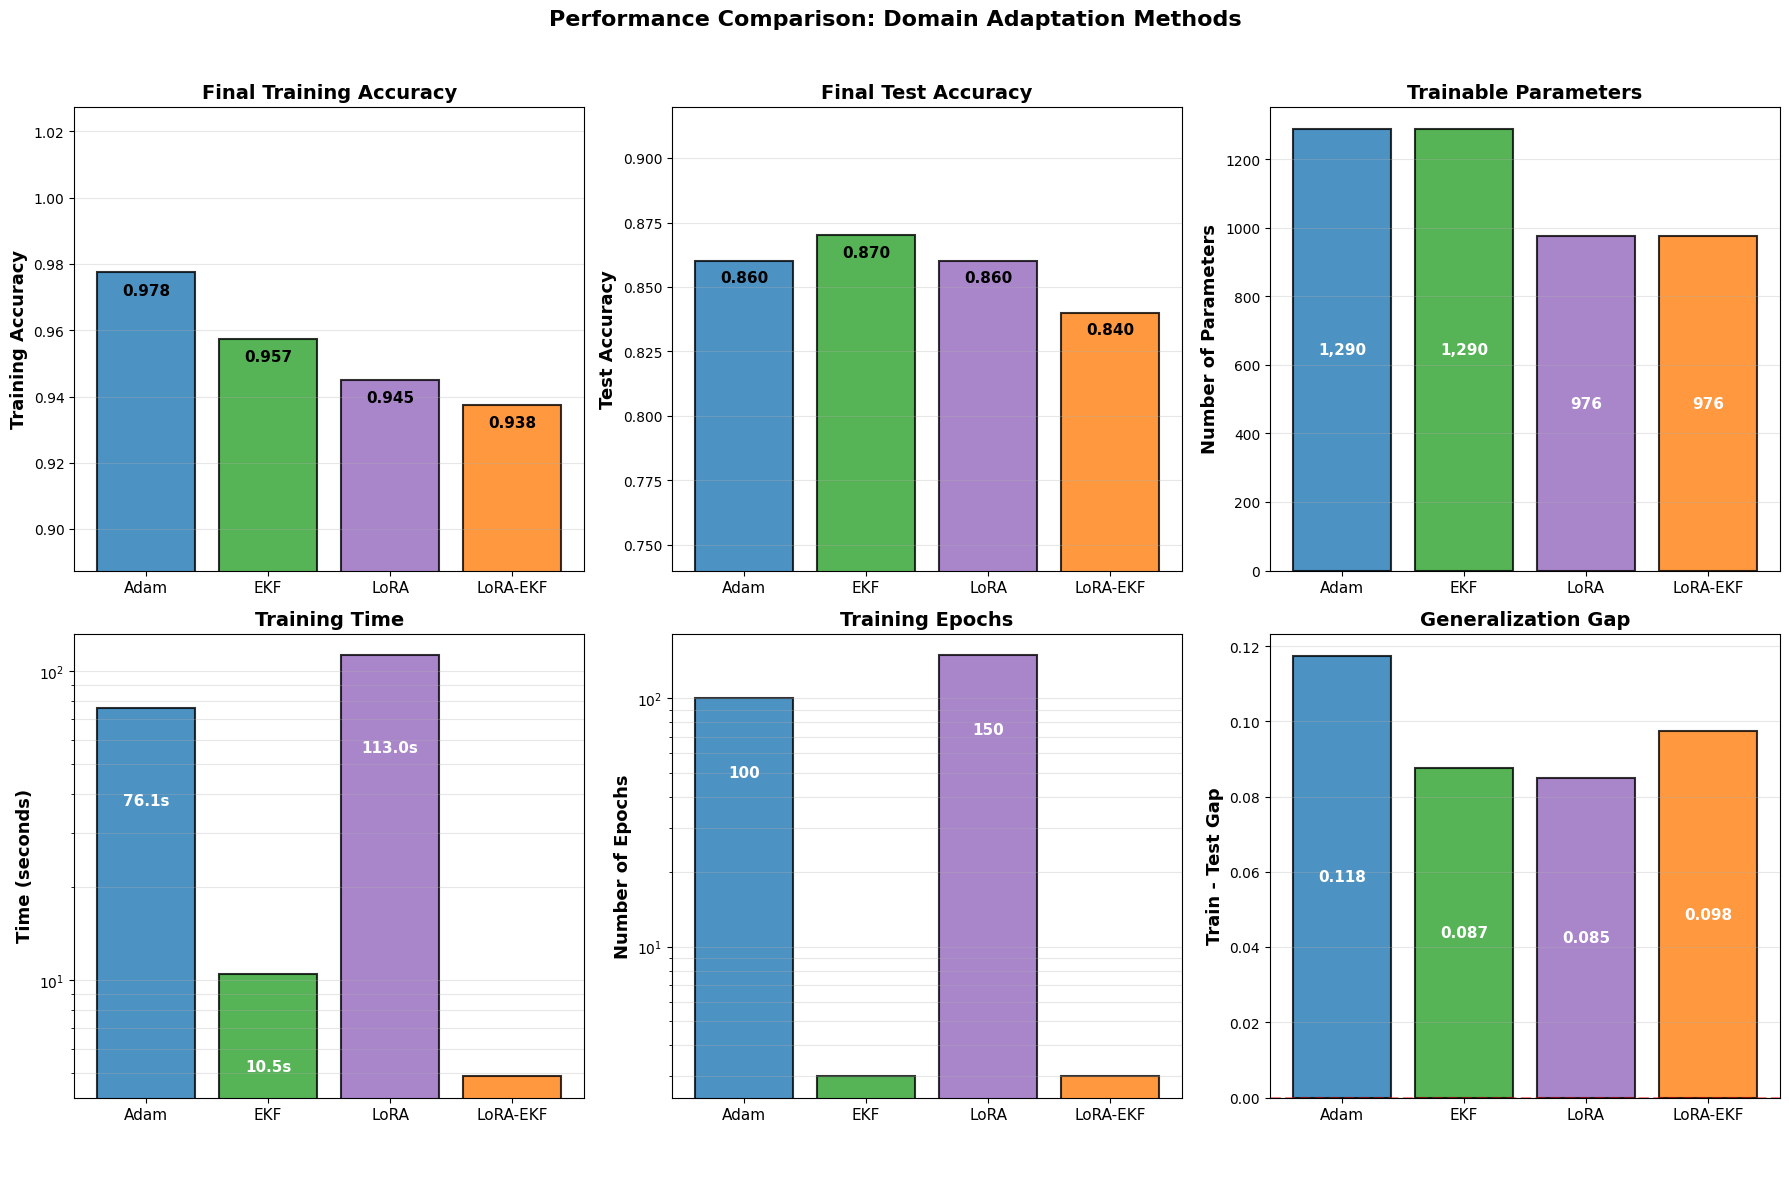

In [30]:
results = {
    'adam': adam_results,
    'ekf': ekf_results,
    'lora': lora_results,
    'lora_ekf': lora_ekf_results
}

def plot_comprehensive_results_v2(results):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    methods = ['adam', 'ekf', 'lora', 'lora_ekf']
    
    colors = {
        'adam': '#1f77b4', 
        'ekf': '#2ca02c',
        'lora': '#9467bd', 
        'lora_ekf': '#ff7f0e'
    }
    labels = {
        'adam': 'Adam', 
        'ekf': 'EKF',
        'lora': 'LoRA', 
        'lora_ekf': 'LoRA-EKF'
    }
    
    method_labels = [labels[m] for m in methods]
    x_pos = np.arange(len(methods))
    
    ax = axes[0, 0]
    final_train_accs = []
    for m in methods:
        n_epochs = len(results[m]['test_accs_per_epoch'])
        n_batches = len(results[m]['accs']) // n_epochs
        final_train_acc = np.mean(results[m]['accs'][-n_batches:])
        final_train_accs.append(final_train_acc)
    
    bars = ax.bar(x_pos, final_train_accs, color=[colors[m] for m in methods],
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Training Accuracy', fontsize=13, fontweight='bold')
    ax.set_title('Final Training Accuracy', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(method_labels, fontsize=11)
    y_range = max(final_train_accs) - min(final_train_accs)
    ax.set_ylim([min(final_train_accs) - 0.05, max(final_train_accs) + 0.05])
    for i, v in enumerate(final_train_accs):
        ax.text(i, v - y_range * 0.08, f'{v:.3f}', ha='center', va='top',
                fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    ax = axes[0, 1]
    test_accs = [results[m]['test_acc'] for m in methods]
    bars = ax.bar(x_pos, test_accs, color=[colors[m] for m in methods],
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Test Accuracy', fontsize=13, fontweight='bold')
    ax.set_title('Final Test Accuracy', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(method_labels, fontsize=11)
    y_range = max(test_accs) - min(test_accs)
    ax.set_ylim([min(test_accs) - 0.1, max(test_accs) + 0.05])
    for i, v in enumerate(test_accs):
        ax.text(i, v - y_range * 0.12, f'{v:.3f}', ha='center', va='top',
                fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    
    ax = axes[0, 2]
    n_params_dict = {
        'adam': config.hidden_sizes[0] * config.num_classes + config.num_classes,
        'ekf': config.hidden_sizes[0] * config.num_classes + config.num_classes,
        'lora': config.hidden_sizes[0] * config.lora_rank + config.lora_rank * config.num_classes + config.num_classes,
        'lora_ekf': config.hidden_sizes[0] * config.lora_rank + config.lora_rank * config.num_classes + config.num_classes
    }
    n_params = [n_params_dict[m] for m in methods]
    bars = ax.bar(x_pos, n_params, color=[colors[m] for m in methods], 
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Number of Parameters', fontsize=13, fontweight='bold')
    ax.set_title('Trainable Parameters', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(method_labels, fontsize=11)
    for i, (v, bar) in enumerate(zip(n_params, bars)):
        y_pos = v / 2
        ax.text(i, y_pos, f'{v:,}', ha='center', va='center',
                fontweight='bold', fontsize=11, color='white')
    ax.grid(True, alpha=0.3, axis='y')
    
    ax = axes[1, 0]
    times = [results[m]['time'] for m in methods]
    bars = ax.bar(x_pos, times, color=[colors[m] for m in methods],
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Time (seconds)', fontsize=13, fontweight='bold')
    ax.set_title('Training Time', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(method_labels, fontsize=11)
    ax.set_yscale('log')
    for i, (v, bar) in enumerate(zip(times, bars)):
        y_pos = v / 2
        ax.text(i, y_pos, f'{v:.1f}s', ha='center', va='center',
                fontweight='bold', fontsize=11, color='white')
    ax.grid(True, alpha=0.3, axis='y', which='both')
    
    ax = axes[1, 1]
    n_epochs_dict = {
        'adam': config.adam_epochs,
        'ekf': config.ekf_epochs,
        'lora': config.lora_epochs,
        'lora_ekf': config.lora_ekf_epochs
    }
    n_epochs = [n_epochs_dict[m] for m in methods]
    bars = ax.bar(x_pos, n_epochs, color=[colors[m] for m in methods], 
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Number of Epochs', fontsize=13, fontweight='bold')
    ax.set_title('Training Epochs', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(method_labels, fontsize=11)
    ax.set_yscale('log')
    for i, (v, bar) in enumerate(zip(n_epochs, bars)):
        y_pos = v / 2
        ax.text(i, y_pos, f'{v}', ha='center', va='center',
                fontweight='bold', fontsize=11, color='white')
    ax.grid(True, alpha=0.3, axis='y', which='both')
    
    ax = axes[1, 2]
    generalization_gaps = [final_train_accs[i] - test_accs[i] for i in range(len(methods))]
    bars = ax.bar(x_pos, generalization_gaps, color=[colors[m] for m in methods],
                   alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_ylabel('Train - Test Gap', fontsize=13, fontweight='bold')
    ax.set_title('Generalization Gap', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(method_labels, fontsize=11)
    for i, (v, bar) in enumerate(zip(generalization_gaps, bars)):
        y_pos = v / 2
        ax.text(i, y_pos, f'{v:.3f}', ha='center', va='center',
                fontweight='bold', fontsize=11, color='white')
    ax.grid(True, alpha=0.3, axis='y')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2, alpha=0.5)
    
    plt.suptitle('Performance Comparison: Domain Adaptation Methods',
                 fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    plt.savefig('/mnt/user-data/outputs/comprehensive_results_v2.png',
                dpi=300, bbox_inches='tight')
    print("\nComprehensive results v2 saved!")
    plt.show()

plot_comprehensive_results_v2(results)

### Benchmarking

In [18]:

multi_seed_results = {
    'adam': {'test_accs': [], 'test_losses': [], 'times': []},
    'ekf': {'test_accs': [], 'test_losses': [], 'times': []},
    'lora': {'test_accs': [], 'test_losses': [], 'times': []},
    'lora_ekf': {'test_accs': [], 'test_losses': [], 'times': []},
}

N_SEEDS = 5
BASE_SEED = 42

# Disable verbose output for multi-seed runs
config.print_batch_metrics = False
config.verify_covariance = False

In [19]:
def get_data_for_seed(seed):

    X_full, y_full, X_test_full, y_test_full = load_mnist(
        normalize=True, 
        n_train_samples=60000, 
        n_test_samples=10000
    )


    X_pre, y_pre = stratified_sample(
        X_full, y_full, 
        config.pretrain_samples, 
        seed=seed
    )
    
    rng = np.random.RandomState(seed)
    perm = rng.permutation(len(X_full))
    
    # Pretrain indices
    pre_idx = perm[:config.pretrain_samples]
    X_pre = X_full[pre_idx]
    y_pre = y_full[pre_idx]
    
    # Finetune indices
    remaining_idx = perm[config.pretrain_samples:] 
    X_remaining = X_full[remaining_idx]
    y_remaining = y_full[remaining_idx]
    
    X_fine_raw, y_fine = stratified_sample(
        X_remaining, y_remaining,
        config.finetune_samples,
        seed=seed+1
    )

    X_fine_shifted = apply_domain_shift(
        X_fine_raw, 
        shift_type=config.shift_type,
        rotation_angle=config.rotation_angle,
        contrast=config.contrast,
        brightness=config.brightness
    )

    # Test set logic
    X_test_raw, y_test = stratified_sample(
        X_test_full, y_test_full,
        config.finetune_test_samples,
        seed=seed+2
    )
    
    X_test_shifted = apply_domain_shift(
        X_test_raw,
        shift_type=config.shift_type,
        rotation_angle=config.rotation_angle,
        contrast=config.contrast,
        brightness=config.brightness
    )

    return X_pre, y_pre, X_fine_shifted, y_fine, X_test_shifted, y_test

In [20]:
# ADAM - MULTI-SEED EVALUATION

print("\n" + "="*80)
print("ADAM - RUNNING 5-SEED EVALUATION")
print("="*80)

# 1. CONFIGURATION FOR ADAM
config.print_batch_metrics = False
config.finetune_lr = 2e-4 
config.batch_size = 1
config.adam_epochs = 100

for seed_idx in range(N_SEEDS):
    current_seed = BASE_SEED + seed_idx * 100
    print(f"  Seed {seed_idx + 1}/{N_SEEDS} (seed={current_seed})...", end=" ", flush=True)

    # 2. LOAD DATA (Clean Split)
    X_train_pre, y_train_pre, X_train_fine, y_train_fine, X_test_fine, y_test_fine = get_data_for_seed(current_seed)
    print(X_train_pre.shape, y_train_pre.shape, X_train_fine.shape, y_train_fine.shape, X_test_fine.shape, y_test_fine.shape)
    
    # 3. MAP VARIABLES 
    # Pair 1: Pretraining Data
    X_train_s = X_train_pre
    y_train_s = y_train_pre

    # Pair 2: Finetuning Data (Shifted)
    X_train_shifted_s = X_train_fine
    y_train_shifted_s = y_train_fine

    # Pair 3: Test Data
    X_test_shifted_s = X_test_fine
    y_test_s = y_test_fine   

    # 4. PRETRAIN (Uses X_train_s and y_train_s)
    rng = nnx.Rngs(current_seed)
    #model = MLP(config.hidden_sizes, config.num_classes, rng)
    model = CNN_MLP(
    cnn_channels=config.cnn_channels,
    mlp_hidden_sizes=config.hidden_sizes,
    num_classes=config.num_classes,
    rngs=rng,
    dropout_rate=config.dropout_rate)
    
    state = create_train_state(model, config.pretrain_lr)

    n_batches = int(np.ceil(len(X_train_s) / config.pretrain_batch_size)) # Use pretrain batch size
    for epoch in range(config.pretrain_epochs):
        key = random.PRNGKey(epoch + current_seed)
        perm = random.permutation(key, len(X_train_s))
        
        # Shuffle Pretrain Data
        X_shuffled = X_train_s[perm]
        y_shuffled = y_train_s[perm]
        
        for i in range(n_batches):
            start_idx = i * config.pretrain_batch_size
            end_idx = min((i + 1) * config.pretrain_batch_size, len(X_train_s))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            state, _, _ = pretrain_step(state, (batch_x, batch_y))

    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    pretrained_model_s = nnx.merge(graphdef, state.params, other_states)

    # 5. FINE-TUNE ADAM (Uses X_train_shifted_s and y_train_shifted_s)
    adam_model_s = nnx.clone(pretrained_model_s)
    adam_state_s = create_output_only_train_state(adam_model_s, config.finetune_lr)

    start_time = time.time()
    n_batches_per_epoch = int(np.ceil(len(X_train_shifted_s) / config.batch_size))

    for epoch in range(config.adam_epochs):
        key = random.PRNGKey(epoch + current_seed + 1000)
        perm = random.permutation(key, len(X_train_shifted_s))
        
        # Shuffle Finetune Data
        X_shuffled = X_train_shifted_s[perm]
        y_shuffled = y_train_shifted_s[perm]

        for batch_idx in range(n_batches_per_epoch):
            start_idx = batch_idx * config.batch_size
            end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted_s))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            adam_state_s, _, _ = finetune_step(adam_state_s, (batch_x, batch_y))

    adam_time = time.time() - start_time

    # 6. EVALUATE (Uses X_test_shifted_s and y_test_s)
    test_logits = adam_state_s.apply_fn(adam_state_s.params, X_test_shifted_s, training=False)
    adam_acc = float(compute_accuracy(test_logits, y_test_s))
    adam_loss = float(cross_entropy_loss(test_logits, y_test_s))

    multi_seed_results['adam']['test_accs'].append(adam_acc)
    multi_seed_results['adam']['test_losses'].append(adam_loss)
    multi_seed_results['adam']['times'].append(adam_time)

    print(f"Acc={adam_acc:.4f}, Loss={adam_loss:.4f}, Time={adam_time:.2f}s")

print(f"ADAM Mean: Acc={np.mean(multi_seed_results['adam']['test_accs']):.4f} ± {np.std(multi_seed_results['adam']['test_accs']):.4f}")


ADAM - RUNNING 5-SEED EVALUATION
  Seed 1/5 (seed=42)... Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (10000, 784), dtype=float32
(10000, 784) (10000,) (400, 784) (400,) (100, 784) (100,)
Acc=0.8700, Loss=0.3996, Time=41.52s
  Seed 2/5 (seed=142)... Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (10000, 784), dtype=float32
(10000, 784) (10000,) (400, 784) (400,) (100, 784) (100,)
Acc=0.9100, Loss=0.3025, Time=41.58s
  Seed 3/5 (seed=242)... Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (10000, 784), dtype=float32
(10000, 784) (10000,) (400, 784) (400,) (100, 784) (100,)
Acc=0.7900, Loss=0.7260, Time=41.11s
  Seed 4/5 (seed=342)... Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (10000, 784), dtype=float32
(10000, 784) (10000,) (400, 784) (400,) (100, 784) (100,)
Acc=0.8100, Loss=0.5076, Time=41.41s
  Seed 5/5 (seed=442)... Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (10000, 784), dtype=float32
(10000, 784) (10000,) (400, 784)

In [21]:
# EKF - MULTI-SEED EVALUATION
print("\n" + "="*80)
print("EKF - RUNNING 5-SEED EVALUATION")
print("="*80)

config.prior_variance = 1.0
config.dynamics_sigma = 5e-4
config.observation_noise = 7e-2
config.ekf_epochs = 3
config.print_batch_metrics = False 
config.batch_size = 400

for seed_idx in range(N_SEEDS):
    current_seed = BASE_SEED + seed_idx * 100
    print(f"  Seed {seed_idx + 1}/{N_SEEDS} (seed={current_seed})...", end=" ", flush=True)

    X_train_pre, y_train_pre, X_train_fine, y_train_fine, X_test_fine, y_test_fine = get_data_for_seed(current_seed)
    print(X_train_pre.shape, y_train_pre.shape, X_train_fine.shape, y_train_fine.shape, X_test_fine.shape, y_test_fine.shape)
    
    X_train_s = X_train_pre
    y_train_s = y_train_pre

    X_train_shifted_s = X_train_fine
    y_train_shifted_s = y_train_fine

    X_test_shifted_s = X_test_fine
    y_test_s = y_test_fine

    rng = nnx.Rngs(current_seed)
    #model = MLP(config.hidden_sizes, config.num_classes, rng)
    model = CNN_MLP(
    cnn_channels=config.cnn_channels,
    mlp_hidden_sizes=config.hidden_sizes,
    num_classes=config.num_classes,
    rngs=rng,
    dropout_rate=config.dropout_rate)
    state = create_train_state(model, config.pretrain_lr)

    n_batches = int(np.ceil(len(X_train_s) / config.pretrain_batch_size))
    
    for epoch in range(config.pretrain_epochs):
        key = random.PRNGKey(epoch + current_seed)
        perm = random.permutation(key, len(X_train_s))
        
        X_shuffled = X_train_s[perm]
        y_shuffled = y_train_s[perm]
        
        for i in range(n_batches):
            start_idx = i * config.pretrain_batch_size
            end_idx = min((i + 1) * config.pretrain_batch_size, len(X_train_s))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            state, _, _ = pretrain_step(state, (batch_x, batch_y))

    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    pretrained_model_s = nnx.merge(graphdef, state.params, other_states)


    ekf_model_s = nnx.clone(pretrained_model_s)
    P_ekf_s = None

    start_time = time.time()

    n_batches_per_epoch = int(np.ceil(len(X_train_shifted_s) / config.batch_size))

    for epoch in range(config.ekf_epochs):
        key = random.PRNGKey(epoch + current_seed + 2000)
        perm = random.permutation(key, len(X_train_shifted_s))
        
        X_shuffled = X_train_shifted_s[perm]

        y_shuffled = y_train_shifted_s[perm] 

        for batch_idx in range(n_batches_per_epoch):
            start_idx = batch_idx * config.batch_size
            end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted_s))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            
            ekf_model_s, P_ekf_s = ekf_update(ekf_model_s, batch_x, batch_y, P_ekf_s, use_full_cov=True)

    ekf_time = time.time() - start_time

    test_logits = ekf_model_s(X_test_shifted_s, training=False)
    ekf_acc = float(compute_accuracy(test_logits, y_test_s))
    ekf_loss = float(cross_entropy_loss(test_logits, y_test_s))

    multi_seed_results['ekf']['test_accs'].append(ekf_acc)
    multi_seed_results['ekf']['test_losses'].append(ekf_loss)
    multi_seed_results['ekf']['times'].append(ekf_time)

    print(f"Acc={ekf_acc:.4f}, Loss={ekf_loss:.4f}, Time={ekf_time:.2f}s")

print(f"EKF Mean: Acc={np.mean(multi_seed_results['ekf']['test_accs']):.4f} ± {np.std(multi_seed_results['ekf']['test_accs']):.4f}")


EKF - RUNNING 5-SEED EVALUATION
  Seed 1/5 (seed=42)... Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (10000, 784), dtype=float32
(10000, 784) (10000,) (400, 784) (400,) (100, 784) (100,)
  [EKF] Initializing covariance: P0 = 1.0 × I (1290×1290)
Acc=0.8700, Loss=0.4754, Time=7.32s
  Seed 2/5 (seed=142)... Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (10000, 784), dtype=float32
(10000, 784) (10000,) (400, 784) (400,) (100, 784) (100,)
  [EKF] Initializing covariance: P0 = 1.0 × I (1290×1290)
Acc=0.9200, Loss=0.2683, Time=7.40s
  Seed 3/5 (seed=242)... Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (10000, 784), dtype=float32
(10000, 784) (10000,) (400, 784) (400,) (100, 784) (100,)
  [EKF] Initializing covariance: P0 = 1.0 × I (1290×1290)
Acc=0.7200, Loss=3.1318, Time=7.26s
  Seed 4/5 (seed=342)... Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (10000, 784), dtype=float32
(10000, 784) (10000,) (400, 784) (400,) (100, 784) (100,)
  [EKF] In

In [22]:
# multi_seed_results['ekf']['test_accs'] = []
# multi_seed_results['ekf']['test_losses'] = []
# multi_seed_results['ekf']['times'] = []

In [23]:
# LORA - MULTI-SEED EVALUATION
print("\n" + "="*80)
print("LORA - RUNNING 5-SEED EVALUATION")
print("="*80)

config.print_batch_metrics = False
config.lora_finetune_lr = 2e-4
config.batch_size = 1
config.lora_epochs = 150
config.lora_rank = 7
config.lora_alpha = 7.0

for seed_idx in range(N_SEEDS):
    current_seed = BASE_SEED + seed_idx * 100
    print(f"  Seed {seed_idx + 1}/{N_SEEDS} (seed={current_seed})...", end=" ", flush=True)

    X_train_pre, y_train_pre, X_train_fine, y_train_fine, X_test_fine, y_test_fine = get_data_for_seed(current_seed)
    print(X_train_pre.shape, y_train_pre.shape, X_train_fine.shape, y_train_fine.shape, X_test_fine.shape, y_test_fine.shape)

    X_train_s = X_train_pre
    y_train_s = y_train_pre

    X_train_shifted_s = X_train_fine
    y_train_shifted_s = y_train_fine

    X_test_shifted_s = X_test_fine
    y_test_s = y_test_fine

    rng = nnx.Rngs(current_seed)
    #model = MLP(config.hidden_sizes, config.num_classes, rng)
    model = CNN_MLP(
    cnn_channels=config.cnn_channels,
    mlp_hidden_sizes=config.hidden_sizes,
    num_classes=config.num_classes,
    rngs=rng,
    dropout_rate=config.dropout_rate)
    state = create_train_state(model, config.pretrain_lr)

    n_batches = int(np.ceil(len(X_train_s) / config.pretrain_batch_size))
    for epoch in range(config.pretrain_epochs):
        key = random.PRNGKey(epoch + current_seed)
        perm = random.permutation(key, len(X_train_s))
        
        X_shuffled = X_train_s[perm]
        y_shuffled = y_train_s[perm]
        
        for i in range(n_batches):
            start_idx = i * config.pretrain_batch_size
            end_idx = min((i + 1) * config.pretrain_batch_size, len(X_train_s))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            state, _, _ = pretrain_step(state, (batch_x, batch_y))

    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    pretrained_model_s = nnx.merge(graphdef, state.params, other_states)

    lora_model_s = create_lora_model(pretrained_model_s, config.lora_rank, config.lora_alpha)
    
    graphdef_lora, trainable_params_s, frozen_params_s = nnx.split(lora_model_s, is_lora_trainable, ...)
    
    tx = optax.adam(config.lora_finetune_lr)
    opt_state_s = tx.init(trainable_params_s)

    start_time = time.time()
    n_batches_per_epoch = int(np.ceil(len(X_train_shifted_s) / config.batch_size))

    for epoch in range(config.lora_epochs):
        key = random.PRNGKey(epoch + current_seed + 4000)
        perm = random.permutation(key, len(X_train_shifted_s))
        
        X_shuffled = X_train_shifted_s[perm]

        y_shuffled = y_train_shifted_s[perm] 

        for batch_idx in range(n_batches_per_epoch):
            start_idx = batch_idx * config.batch_size
            end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted_s))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            
            trainable_params_s, opt_state_s, _, _ = lora_train_step_jitted(
                graphdef_lora, trainable_params_s, frozen_params_s, opt_state_s, (batch_x, batch_y)
            )

    lora_time = time.time() - start_time

    updated_state = nnx.State.merge(trainable_params_s, frozen_params_s)
    nnx.update(lora_model_s, updated_state)

    test_logits = lora_model_s(X_test_shifted_s, training=False)
    lora_acc = float(compute_accuracy(test_logits, y_test_s))
    lora_loss = float(cross_entropy_loss(test_logits, y_test_s))

    multi_seed_results['lora']['test_accs'].append(lora_acc)
    multi_seed_results['lora']['test_losses'].append(lora_loss)
    multi_seed_results['lora']['times'].append(lora_time)

    print(f"Acc={lora_acc:.4f}, Loss={lora_loss:.4f}, Time={lora_time:.2f}s")

print(f"LoRA Mean: Acc={np.mean(multi_seed_results['lora']['test_accs']):.4f} ± {np.std(multi_seed_results['lora']['test_accs']):.4f}")


LORA - RUNNING 5-SEED EVALUATION
  Seed 1/5 (seed=42)... Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (10000, 784), dtype=float32
(10000, 784) (10000,) (400, 784) (400,) (100, 784) (100,)
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 7.0/7 = 1.0000
Acc=0.8900, Loss=0.4188, Time=65.50s
  Seed 2/5 (seed=142)... Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (10000, 784), dtype=float32
(10000, 784) (10000,) (400, 784) (400,) (100, 784) (100,)
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 7.0/7 = 1.0000
Acc=0.9000, Loss=0.3479, Time=64.95s
  Seed 3/5 (seed=242)... Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (10000, 784), dtype=float32
(10000, 784) (10000,) (400, 784) (400,) (100, 784) (100,)
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 7.0/7 = 1.0000
Acc=0.8200, Loss=0.8289, Time=64.57s
  Seed 4/5 (seed=342)... Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (1000

In [24]:
# LORA-EKF: Full EKF on LoRA Parameters

def lora_ekf_update(model, X_batch, y_batch, P_previous=None, step=0):

    output_layer = model.output

    output_state = nnx.state(output_layer, nnx.Param)

    trainable_dict = {}

    if 'lora' in output_state:
        trainable_dict['lora'] = output_state['lora']

    if 'bias' in output_state:
        trainable_dict['bias'] = output_state['bias']

    flat_params, unflatten_fn = ravel_pytree(trainable_dict)
    state_dim = flat_params.size

    #if step == 0: # need to comment this printing as we are not handling step var in the training loop
    #    print(f"  [LoRA-EKF] Trainable params: {state_dim} parameters")
    #    print(f"  [LoRA-EKF] Keys: {list(trainable_dict.keys())}")

    frozen_kernel = output_state['kernel']

    def forward_fn(params_flat, x):
        params = unflatten_fn(params_flat)

        temp_state = {'kernel': frozen_kernel}
        temp_state.update(params)

        output_graphdef, _, other_states = nnx.split(output_layer, nnx.Param, ...)
        output_layer_temp = nnx.merge(output_graphdef, temp_state, other_states)

        features = model.extract_features(x)
        logits = output_layer_temp(features)

        return jax.nn.softmax(logits)

    initial_mean = flat_params

    if P_previous is None:
        initial_covariance = jnp.eye(state_dim) * config.prior_variance * 1e-8 
        print(f"  [LoRA-EKF] Initializing covariance: P0 = {config.prior_variance} × I ({state_dim}×{state_dim})")
    else:
        initial_covariance = P_previous
        if step % 50 == 0:
            verify_covariance_matrix(P_previous, "P_lora_prev", step)

    dynamics_function = lambda w, x: w
    dynamics_covariance = jnp.eye(state_dim) * config.dynamics_sigma

    def emission_mean_function(w, x):
        return forward_fn(w, x)

    def emission_cov_function(w, x):
        probs = emission_mean_function(w, x)
        return jnp.diag(probs * (1 - probs)) + config.observation_noise * jnp.eye(config.num_classes)

    params = ParamsGGSSM(
        initial_mean=initial_mean,
        initial_covariance=initial_covariance,
        dynamics_function=dynamics_function,
        dynamics_covariance=dynamics_covariance,
        emission_mean_function=emission_mean_function,
        emission_cov_function=emission_cov_function
    )

    emissions = jax.nn.one_hot(y_batch, config.num_classes)
    inputs = X_batch

    ekf_post = conditional_moments_gaussian_filter(
        params,
        EKFIntegrals(),
        emissions,
        inputs
    )

    updated_params_flat = ekf_post.filtered_means[-1]
    updated_covariance = ekf_post.filtered_covariances[-1]

    if step % 50 == 0:
        verify_covariance_matrix(updated_covariance, "P_lora_updated", step)
        compare_covariances(P_previous, updated_covariance, "P_LoRA", step)

    updated_params = unflatten_fn(updated_params_flat)

    nnx.update(output_layer, updated_params)

    return model, updated_covariance

print("LoRA-EKF update function defined")

LoRA-EKF update function defined


In [34]:
# LORA-EKF - MULTI-SEED EVALUATION

print("\n" + "="*80)
print("LORA-EKF - RUNNING 5-SEED EVALUATION")
print("="*80)

config.lora_rank = 7
config.lora_alpha = 7.0
config.batch_size = 400
config.lora_ekf_epochs = 3
config.prior_variance = 1.0
config.dynamics_sigma = 1e-4
config.observation_noise = 3e-2 #3e-2 #4.5e-2
config.print_batch_metrics = False

for seed_idx in range(N_SEEDS):
    current_seed = BASE_SEED + seed_idx * 100
    print(f"  Seed {seed_idx + 1}/{N_SEEDS} (seed={current_seed})...", end=" ", flush=True)

    X_train_pre, y_train_pre, X_train_fine, y_train_fine, X_test_fine, y_test_fine = get_data_for_seed(current_seed)
    print(X_train_pre.shape, y_train_pre.shape, X_train_fine.shape, y_train_fine.shape, X_test_fine.shape, y_test_fine.shape)

    X_train_s = X_train_pre
    y_train_s = y_train_pre

    X_train_shifted_s = X_train_fine
    y_train_shifted_s = y_train_fine

    X_test_shifted_s = X_test_fine
    y_test_s = y_test_fine

    rng = nnx.Rngs(current_seed)
    #model = MLP(config.hidden_sizes, config.num_classes, rng)
    model = CNN_MLP(
    cnn_channels=config.cnn_channels,
    mlp_hidden_sizes=config.hidden_sizes,
    num_classes=config.num_classes,
    rngs=rng,
    dropout_rate=config.dropout_rate)
    state = create_train_state(model, config.pretrain_lr)

    n_batches = int(np.ceil(len(X_train_s) / config.pretrain_batch_size))
    for epoch in range(config.pretrain_epochs):
        key = random.PRNGKey(epoch + current_seed)
        perm = random.permutation(key, len(X_train_s))
        
        X_shuffled = X_train_s[perm]
        y_shuffled = y_train_s[perm]
        
        for i in range(n_batches):
            start_idx = i * config.pretrain_batch_size
            end_idx = min((i + 1) * config.pretrain_batch_size, len(X_train_s))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            state, _, _ = pretrain_step(state, (batch_x, batch_y))

    graphdef, params, other_states = nnx.split(model, nnx.Param, ...)
    pretrained_model_s = nnx.merge(graphdef, state.params, other_states)


    lora_ekf_model_s = create_lora_model(pretrained_model_s, config.lora_rank, config.lora_alpha)
    P_lora_ekf_s = None

    start_time = time.time()
    n_batches_per_epoch = int(np.ceil(len(X_train_shifted_s) / config.batch_size))

    for epoch in range(config.lora_ekf_epochs):
        key = random.PRNGKey(epoch + current_seed + 6000)
        perm = random.permutation(key, len(X_train_shifted_s))
        
        X_shuffled = X_train_shifted_s[perm]

        y_shuffled = y_train_shifted_s[perm] 

        for batch_idx in range(n_batches_per_epoch):
            start_idx = batch_idx * config.batch_size
            end_idx = min((batch_idx + 1) * config.batch_size, len(X_train_shifted_s))
            batch_x = X_shuffled[start_idx:end_idx]
            batch_y = y_shuffled[start_idx:end_idx]
            
            lora_ekf_model_s, P_lora_ekf_s = lora_ekf_update(lora_ekf_model_s, batch_x, batch_y, P_lora_ekf_s)

    lora_ekf_time = time.time() - start_time

    test_logits = lora_ekf_model_s(X_test_shifted_s, training=False)
    lora_ekf_acc = float(compute_accuracy(test_logits, y_test_s))
    lora_ekf_loss = float(cross_entropy_loss(test_logits, y_test_s))

    multi_seed_results['lora_ekf']['test_accs'].append(lora_ekf_acc)
    multi_seed_results['lora_ekf']['test_losses'].append(lora_ekf_loss)
    multi_seed_results['lora_ekf']['times'].append(lora_ekf_time)

    print(f"Acc={lora_ekf_acc:.4f}, Loss={lora_ekf_loss:.4f}, Time={lora_ekf_time:.2f}s")

print(f"LoRA-EKF Mean: Acc={np.mean(multi_seed_results['lora_ekf']['test_accs']):.4f} ± {np.std(multi_seed_results['lora_ekf']['test_accs']):.4f}")


LORA-EKF - RUNNING 5-SEED EVALUATION
  Seed 1/5 (seed=42)... Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (10000, 784), dtype=float32
(10000, 784) (10000,) (400, 784) (400,) (100, 784) (100,)
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 7.0/7 = 1.0000
  [LoRA-EKF] Initializing covariance: P0 = 1.0 × I (976×976)
Acc=0.8400, Loss=0.4691, Time=4.70s
  Seed 2/5 (seed=142)... Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (10000, 784), dtype=float32
(10000, 784) (10000,) (400, 784) (400,) (100, 784) (100,)
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 7.0/7 = 1.0000
  [LoRA-EKF] Initializing covariance: P0 = 1.0 × I (976×976)
Acc=0.9000, Loss=0.3516, Time=4.72s
  Seed 3/5 (seed=242)... Data loaded:
  Train: (60000, 784), dtype=float32
  Test: (10000, 784), dtype=float32
(10000, 784) (10000,) (400, 784) (400,) (100, 784) (100,)
  LoRA layer initialized with pretrained weights
  LoRA scaling factor: 7.0/7 = 1.0000
 

In [33]:
# multi_seed_results['lora_ekf']['test_accs'] = []
# multi_seed_results['lora_ekf']['test_losses'] = []
# multi_seed_results['lora_ekf']['times'] = []


STATISTICAL ANALYSIS

Method          Test Accuracy                       Test Loss                           Time (s)                      
-------------------------------------------------------------------------------------------------------------------
Adam            0.8620 ± 0.0610 | [0.7863, 0.9377]  0.4613 ± 0.1654 | [0.2559, 0.6666]  41.42 ± 0.19 | [41.19, 41.66] 
EKF             0.8400 ± 0.0803 | [0.7403, 0.9397]  0.9808 ± 1.2092 | [-0.5207, 2.4823] 7.24 ± 0.13 | [7.08, 7.40]    
LoRA            0.8660 ± 0.0527 | [0.8005, 0.9315]  0.5354 ± 0.1920 | [0.2970, 0.7738]  65.14 ± 0.45 | [64.59, 65.70] 
LoRA-EKF        0.8400 ± 0.0474 | [0.7811, 0.8989]  0.5340 ± 0.1735 | [0.3187, 0.7494]  4.72 ± 0.03 | [4.69, 4.76]    

Multi-seed results plot saved!


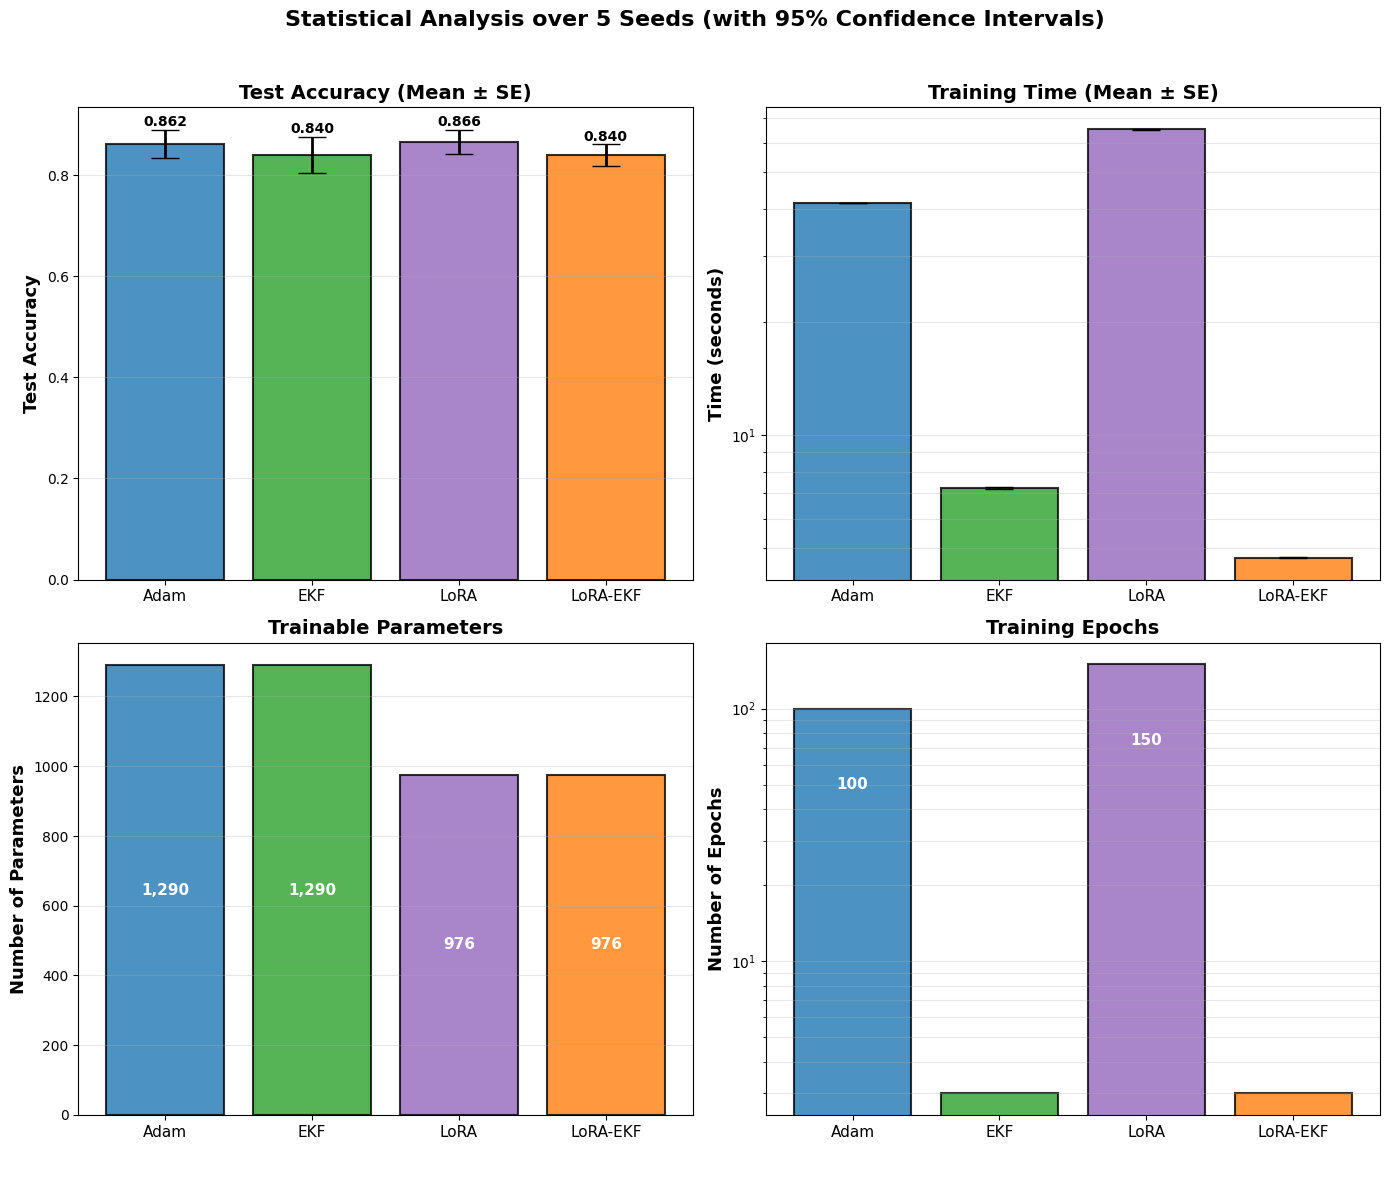


Multi-seed data saved to multi_seed_data.npz


In [35]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("STATISTICAL ANALYSIS")
print("="*80)

def compute_stats(values):
    values = np.array(values)
    n = len(values)
    if n == 0: return {'mean': 0, 'std': 0, 'stderr': 0, 'ci_lower': 0, 'ci_upper': 0, 'ci_margin': 0}
    
    mean = np.mean(values)
    std = np.std(values, ddof=1)
    stderr = std / np.sqrt(n)

    confidence = 0.95
    dof = n - 1
    if dof > 0:
        t_value = stats.t.ppf((1 + confidence) / 2, dof)
    else:
        t_value = 0
        
    ci_margin = t_value * stderr
    ci_lower = mean - ci_margin
    ci_upper = mean + ci_margin

    return {
        'mean': mean,
        'std': std,
        'stderr': stderr,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'ci_margin': ci_margin
    }

statistics = {}
methods = ['adam', 'ekf', 'lora', 'lora_ekf']
method_labels = {
    'adam': 'Adam', 'ekf': 'EKF',
    'lora': 'LoRA', 'lora_ekf': 'LoRA-EKF'
}

# --- 1. Compute Statistics ---
for method in methods:
    statistics[method] = {
        'test_acc': compute_stats(multi_seed_results[method]['test_accs']),
        'test_loss': compute_stats(multi_seed_results[method]['test_losses']),
        'time': compute_stats(multi_seed_results[method]['times'])
    }

# --- 2. Print Text Table ---
print(f"\n{'Method':<15} {'Test Accuracy':<35} {'Test Loss':<35} {'Time (s)':<30}")
print("-" * 115)

for method in methods:
    acc_stats = statistics[method]['test_acc']
    loss_stats = statistics[method]['test_loss']
    time_stats = statistics[method]['time']

    acc_str = f"{acc_stats['mean']:.4f} ± {acc_stats['std']:.4f} | [{acc_stats['ci_lower']:.4f}, {acc_stats['ci_upper']:.4f}]"
    loss_str = f"{loss_stats['mean']:.4f} ± {loss_stats['std']:.4f} | [{loss_stats['ci_lower']:.4f}, {loss_stats['ci_upper']:.4f}]"
    time_str = f"{time_stats['mean']:.2f} ± {time_stats['std']:.2f} | [{time_stats['ci_lower']:.2f}, {time_stats['ci_upper']:.2f}]"

    print(f"{method_labels[method]:<15} {acc_str:<35} {loss_str:<35} {time_str:<30}")

# --- 3. Visualization (2x2 Grid) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

colors = {
    'adam': '#1f77b4', 'ekf': '#2ca02c',
    'lora': '#9467bd', 'lora_ekf': '#ff7f0e'
}

method_names = [method_labels[m] for m in methods]
x_pos = np.arange(len(methods))

# === Plot 1: Test Accuracy ===
ax = axes[0, 0]
accs_mean = [statistics[m]['test_acc']['mean'] for m in methods]
accs_stderr = [statistics[m]['test_acc']['stderr'] for m in methods]

bars = ax.bar(x_pos, accs_mean, yerr=accs_stderr, capsize=10,
              color=[colors[m] for m in methods], alpha=0.8,
              edgecolor='black', linewidth=1.5, error_kw={'linewidth': 2})
ax.set_ylabel('Test Accuracy', fontsize=13, fontweight='bold')
ax.set_title('Test Accuracy (Mean ± SE)', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

for i, m in enumerate(accs_mean):
    ax.text(i, m + accs_stderr[i] + 0.001, f'{m:.3f}',
            ha='center', va='bottom', fontweight='bold', fontsize=10)

# === Plot 2: Training Time ===
ax = axes[0, 1]
times_mean = [statistics[m]['time']['mean'] for m in methods]
times_stderr = [statistics[m]['time']['stderr'] for m in methods]

bars = ax.bar(x_pos, times_mean, yerr=times_stderr, capsize=10,
              color=[colors[m] for m in methods], alpha=0.8,
              edgecolor='black', linewidth=1.5, error_kw={'linewidth': 2})
ax.set_ylabel('Time (seconds)', fontsize=13, fontweight='bold')
ax.set_title('Training Time (Mean ± SE)', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, fontsize=11)
ax.set_yscale('log') 
ax.grid(True, alpha=0.3, axis='y', which='both')

# === Plot 3: Trainable Parameters (UPDATED) ===
ax = axes[1, 0]
n_params_dict = {
    'adam': config.hidden_sizes[0] * config.num_classes + config.num_classes,
    'ekf': config.hidden_sizes[0] * config.num_classes + config.num_classes,
    'lora': config.hidden_sizes[0] * config.lora_rank + config.lora_rank * config.num_classes + config.num_classes,
    'lora_ekf': config.hidden_sizes[0] * config.lora_rank + config.lora_rank * config.num_classes + config.num_classes
}
n_params = [n_params_dict[m] for m in methods]

bars = ax.bar(x_pos, n_params, color=[colors[m] for m in methods], 
              alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Parameters', fontsize=13, fontweight='bold')
ax.set_title('Trainable Parameters', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

# --- UPDATED LABEL PLACEMENT ---
for i, v in enumerate(n_params):
    y_pos = v / 2  # Place text in the middle of the bar
    ax.text(i, y_pos, f'{v:,}', ha='center', va='center',
            fontweight='bold', fontsize=11, color='white') # White text for contrast inside bar

# === Plot 4: Epochs ===
ax = axes[1, 1]
n_epochs_dict = {
    'adam': config.adam_epochs,
    'ekf': config.ekf_epochs,
    'lora': config.lora_epochs,
    'lora_ekf': config.lora_ekf_epochs
}
n_epochs = [n_epochs_dict[m] for m in methods]

bars = ax.bar(x_pos, n_epochs, color=[colors[m] for m in methods], 
              alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Epochs', fontsize=13, fontweight='bold')
ax.set_title('Training Epochs', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, fontsize=11)
ax.set_yscale('log')
ax.grid(True, alpha=0.3, axis='y', which='both')

for i, v in enumerate(n_epochs):
    y_pos = v / 2 
    ax.text(i, y_pos, f'{v}', ha='center', va='center',
            fontweight='bold', fontsize=11, color='white')

plt.suptitle(f'Statistical Analysis over {N_SEEDS} Seeds (with 95% Confidence Intervals)',
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig('/mnt/user-data/outputs/multi_seed_results.png', dpi=300, bbox_inches='tight')
print("\nMulti-seed results plot saved!")
plt.show()

np.savez('/mnt/user-data/outputs/multi_seed_data.npz',
         **{f'{method}_{metric}': multi_seed_results[method][metric]
            for method in methods
            for metric in ['test_accs', 'test_losses', 'times']})

print("\nMulti-seed data saved to multi_seed_data.npz")